# Trabalho Final — Detecção de Phishing

Este notebook utiliza o arquivo original `dataset_phishing.csv` e executa as etapas solicitadas no trabalho:

1. Análise Exploratória (EDA) orientada ao negócio
2. Pré-processamento
3. Modelagem supervisionada com comparação de 5 modelos e interpretabilidade
4. Otimização de hiperparâmetros
5. Comparação com abordagem não supervisionada usando K-Means



## Instalação e importação das bibliotecas

In [1]:
!pip install shap xgboost -q
!pip install optuna -q

import optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import xgboost as xgb

from google.colab import files

from sklearn.metrics import adjusted_rand_score
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, precision_recall_curve,
    average_precision_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.7 MB/s eta 0:00:00


## Upload e carregamento do dataset original

Execute a célula abaixo e selecione o arquivo original `dataset_phishing.csv`.


In [2]:
# Carregamento do dataset dataset_phishing.csv
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('dataset_phishing.csv')

Saving dataset_phishing.csv to dataset_phishing.csv


In [3]:
df

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,0,0,0,...,0,0,0,448,5396,3980,0,0,6,legitimate
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,1,1,0,0,...,1,0,0,211,6728,0,0,1,0,phishing
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,1,0,0,...,0,0,0,2809,8515,8,0,1,10,legitimate
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,0,0,0,...,1,0,0,85,2836,2455493,0,0,4,legitimate


## Renomeando as colunas para facilitar o entendimento

Os nomes são alterados somente no DataFrame utilizado pelo notebook. O arquivo CSV original permanece inalterado.

In [4]:
novos_nomes = {
    "url": "url",
    "length_url": "tamanho_url",
    "length_hostname": "tamanho_hostname",
    "ip": "endereco_ip",
    "nb_dots": "quantidade_pontos(.)",
    "nb_hyphens": "quantidade_hifens(-)",
    "nb_at": "quantidade_arrobas(@)",
    "nb_qm": "quantidade_interrogacoes(?)",
    "nb_and": "quantidade_e_comercial(&)",
    "nb_or": "quantidade_ou(\)",
    "nb_eq": "quantidade_igual(=)",
    "nb_underscore": "quantidade_underscore(_)",
    "nb_tilde": "quantidade_til(˜)",
    "nb_percent": "quantidade_percentual(%)",
    "nb_slash": "quantidade_barras(/)",
    "nb_star": "quantidade_asteriscos(*)",
    "nb_colon": "quantidade_dois_pontos(:)",
    "nb_comma": "quantidade_virgulas(,)",
    "nb_semicolumn": "quantidade_ponto_virgula(;)",
    "nb_dollar": "quantidade_cifroes($)",
    "nb_space": "quantidade_espacos( )",
    "nb_www": "quantidade_palavra_www",
    "nb_com": "quantidade_palavra_com",
    "nb_dslash": "quantidade_barras_duplas(//)",
    "http_in_path": "http_no_caminho",
    "https_token": "token_https",
    "ratio_digits_url": "proporcao_digitos_url",
    "ratio_digits_host": "proporcao_digitos_host",
    "punycode": "possui_punycode",
    "port": "possui_porta",
    "tld_in_path": "tld_no_caminho",
    "tld_in_subdomain": "tld_no_subdominio",
    "abnormal_subdomain": "subdominio_anormal",
    "nb_subdomains": "quantidade_subdominios",
    "prefix_suffix": "prefixo_sufixo",
    "random_domain": "dominio_aleatorio",
    "shortening_service": "servico_encurtamento",
    "path_extension": "extensao_no_caminho",
    "nb_redirection": "quantidade_redirecionamentos",
    "nb_external_redirection": "quantidade_redirecionamentos_externos",
    "length_words_raw": "tamanho_palavras_brutas",
    "char_repeat": "repeticao_caracteres",
    "shortest_words_raw": "menor_palavra_bruta",
    "shortest_word_host": "menor_palavra_host",
    "shortest_word_path": "menor_palavra_caminho",
    "longest_words_raw": "maior_palavra_bruta",
    "longest_word_host": "maior_palavra_host",
    "longest_word_path": "maior_palavra_caminho",
    "avg_words_raw": "media_palavras_brutas",
    "avg_word_host": "media_palavras_host",
    "avg_word_path": "media_palavras_caminho",
    "phish_hints": "indicadores_phishing",
    "domain_in_brand": "dominio_na_marca",
    "brand_in_subdomain": "marca_no_subdominio",
    "brand_in_path": "marca_no_caminho",
    "suspecious_tld": "tld_suspeito",
    "statistical_report": "relatorio_estatistico",
    "nb_hyperlinks": "quantidade_hiperlinks",
    "ratio_intHyperlinks": "proporcao_hiperlinks_internos",
    "ratio_extHyperlinks": "proporcao_hiperlinks_externos",
    "ratio_nullHyperlinks": "proporcao_hiperlinks_nulos",
    "nb_extCSS": "quantidade_css_externo",
    "ratio_intRedirection": "proporcao_redirecionamentos_internos",
    "ratio_extRedirection": "proporcao_redirecionamentos_externos",
    "ratio_intErrors": "proporcao_erros_internos",
    "ratio_extErrors": "proporcao_erros_externos",
    "login_form": "possui_formulario_login",
    "external_favicon": "favicon_externo",
    "links_in_tags": "proporcao_links_em_tags",
    "submit_email": "envio_para_email",
    "ratio_intMedia": "proporcao_midias_internas",
    "ratio_extMedia": "proporcao_midias_externas",
    "sfh": "manipulacao_formulario_sfh",
    "iframe": "possui_iframe",
    "popup_window": "possui_popup",
    "safe_anchor": "proporcao_ancoras_seguras",
    "onmouseover": "possui_evento_mouseover",
    "right_clic": "bloqueia_clique_direito",
    "empty_title": "titulo_vazio",
    "domain_in_title": "dominio_no_titulo",
    "domain_with_copyright": "dominio_no_copyright",
    "whois_registered_domain": "dominio_registrado_whois",
    "domain_registration_length": "tempo_registro_dominio",
    "domain_age": "idade_dominio",
    "web_traffic": "trafego_web",
    "dns_record": "possui_registro_dns",
    "google_index": "indexado_google",
    "page_rank": "rank_da_pagina",
    "status": "classificacao"
}

df = df.rename(columns=novos_nomes)
print(df.columns.tolist())

['url', 'tamanho_url', 'tamanho_hostname', 'endereco_ip', 'quantidade_pontos(.)', 'quantidade_hifens(-)', 'quantidade_arrobas(@)', 'quantidade_interrogacoes(?)', 'quantidade_e_comercial(&)', 'quantidade_ou(\\)', 'quantidade_igual(=)', 'quantidade_underscore(_)', 'quantidade_til(˜)', 'quantidade_percentual(%)', 'quantidade_barras(/)', 'quantidade_asteriscos(*)', 'quantidade_dois_pontos(:)', 'quantidade_virgulas(,)', 'quantidade_ponto_virgula(;)', 'quantidade_cifroes($)', 'quantidade_espacos( )', 'quantidade_palavra_www', 'quantidade_palavra_com', 'quantidade_barras_duplas(//)', 'http_no_caminho', 'token_https', 'proporcao_digitos_url', 'proporcao_digitos_host', 'possui_punycode', 'possui_porta', 'tld_no_caminho', 'tld_no_subdominio', 'subdominio_anormal', 'quantidade_subdominios', 'prefixo_sufixo', 'dominio_aleatorio', 'servico_encurtamento', 'extensao_no_caminho', 'quantidade_redirecionamentos', 'quantidade_redirecionamentos_externos', 'tamanho_palavras_brutas', 'repeticao_caracteres',

## 1. Análise exploratória geral, univariada e bivariada

#### Perguntas voltados a negócio:

1. A presença de um endereço IP no lugar do domínio (`endereco_ip`) está mais associada a phishing?

2. Domínios mais novos ou com registro curto (`idade_dominio`) concentram mais phishing?

3. URLs de phishing usam mais redirecionamentos (`quantidade_redirecionamentos`) que as legítimas?

4. URLs com algum serviço de encurtador de links (`servico_encurtamento`) tendem a ser maliciosos?

5. URLs que contenham formulário para login (`possui_formulario_login`) tendem a ser phishing?

6. O ranqueamento do Google (`rank_da_pagina`) serve para medir a qualidade e importância da página, logo como que essa feature impacta no modelo em relação as outras?

7. A quantidade de trafego no site (`trafego_web`) reflete a classificação de legitimate ou phishing, alto e baixo respectivamente?

8. A feature de indicadores de phising (`indicadores_phishing`) possue uma exatidão na correlação das classifições

9. Como partes importantes de uma url, o 'www' (`quantidade_palavra_www`) e 'http' (`http_no_caminho`) indicam uma segurança maior para websites, isso está explicito no dataset?

10. No dataset, notamos duas features ligadas a instigação da ação de usuários em websites: iframes (`possui_iframe`) e popups (`possui_popup`). Essas são métricas que tendenciam o phishing?

#### 1.1 Quantas linhas e colunas tem o dataset?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   url                                    11430 non-null  object 
 1   tamanho_url                            11430 non-null  int64  
 2   tamanho_hostname                       11430 non-null  int64  
 3   endereco_ip                            11430 non-null  int64  
 4   quantidade_pontos(.)                   11430 non-null  int64  
 5   quantidade_hifens(-)                   11430 non-null  int64  
 6   quantidade_arrobas(@)                  11430 non-null  int64  
 7   quantidade_interrogacoes(?)            11430 non-null  int64  
 8   quantidade_e_comercial(&)              11430 non-null  int64  
 9   quantidade_ou(\)                       11430 non-null  int64  
 10  quantidade_igual(=)                    11430 non-null  int64  
 11  qu

In [6]:
#Printando a quantidade de linhas e colunas do dataset
print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

Quantidade de linhas: 11430
Quantidade de colunas: 89


#### 1.2. Analisando valores das features

In [7]:
# Mostra a distribuição de valores de cada coluna (value_counts de todas as colunas de uma vez)
for col in df.columns:
    print(f"\n{'='*50}")
    print(f"Coluna: {col}")
    print(df[col].value_counts())


Coluna: url
url
http://e710z0ear.du.r.appspot.com/c:/users/user/downlo                                                                                           2
http://office365-login-outlook.el.r.appspot.com/wp-content/xp.php                                                                                1
http://graceleadershipfoundation.org/modules/mod_simplefileuploadv1.3/connect/                                                                   1
http://fience.vot.pl/xl                                                                                                                          1
https://usbank.app.link/NquAmzCW01?platform=hootsuite                                                                                            1
                                                                                                                                                ..
http://cns-international2.com/ssss.htm                                                               

#### 1.3. Analisando valores das features separadamente

Realizaremos isso para entender se faz sentido exluir alguma feature pelos valores que trazem e se possui uma relação com a classe de phishing ou legitimate

endereco_ip
0    9709
1    1721
Name: count, dtype: int64




<Axes: >

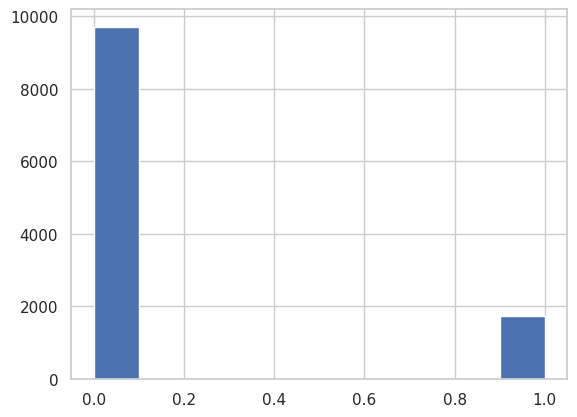

In [8]:
print(f"{df['endereco_ip'].value_counts()}\n\n")
df['endereco_ip'].hist()

#Com essa análise podemos observar que as URLs tendem a não conter um endereço ip, mas sim um domínio DNS

idade_dominio
-1       1781
 7295     197
 3993     156
 3992     117
 5616      73
         ... 
 8732       1
 6639       1
 3011       1
 9547       1
 3932       1
Name: count, Length: 4430, dtype: int64




<Axes: >

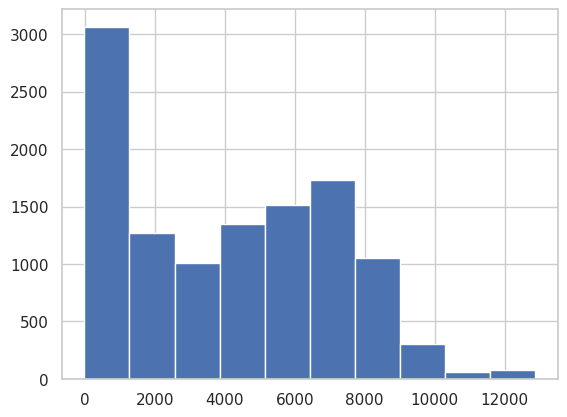

In [9]:
print(f"{df['idade_dominio'].value_counts()}\n\n")
df['idade_dominio'].hist()

#Com essa análise podemos observar que temos URLs com websites de diferentes tempos de publicação, porém o que mais prevalece são os mais "novos"

quantidade_redirecionamentos
0    6775
1    3827
2     662
3     128
4      31
5       6
6       1
Name: count, dtype: int64




<Axes: >

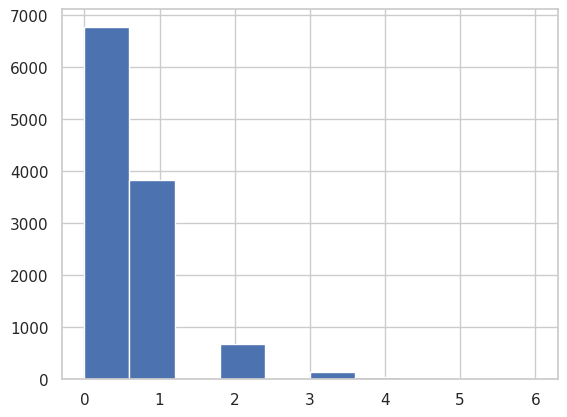

In [10]:
print(f"{df['quantidade_redirecionamentos'].value_counts()}\n\n")
df['quantidade_redirecionamentos'].hist()

#Com essa análise podemos observar que esses links tendem a ter um número menor de redirecionamentos

servico_encurtamento
0    10019
1     1411
Name: count, dtype: int64




<Axes: >

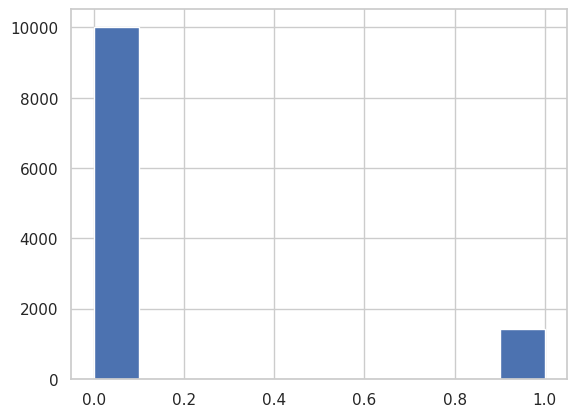

In [11]:
print(f"{df['servico_encurtamento'].value_counts()}\n\n")
df['servico_encurtamento'].hist()

#Com essa análise podemos observar que a maioria das URLs não utiliza encurtadores de links

possui_formulario_login
0    10703
1      727
Name: count, dtype: int64




<Axes: >

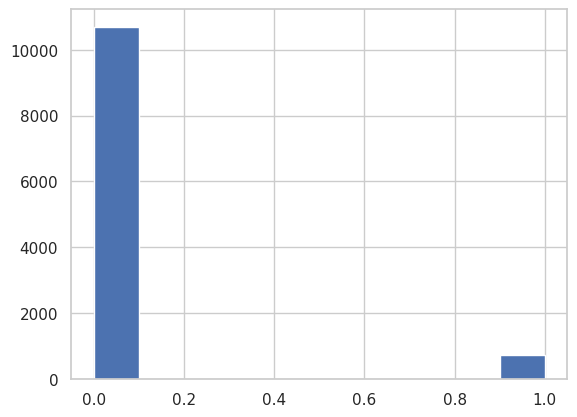

In [12]:
print(f"{df['possui_formulario_login'].value_counts()}\n\n")
df['possui_formulario_login'].hist()

#Com essa análise podemos observar que grande parte dos links não possuem um formulário para login/cadastro

rank_da_pagina
0     2666
5     2057
2     1553
4     1380
3     1232
1      735
6      727
7      509
10     269
8      262
9       40
Name: count, dtype: int64




<Axes: >

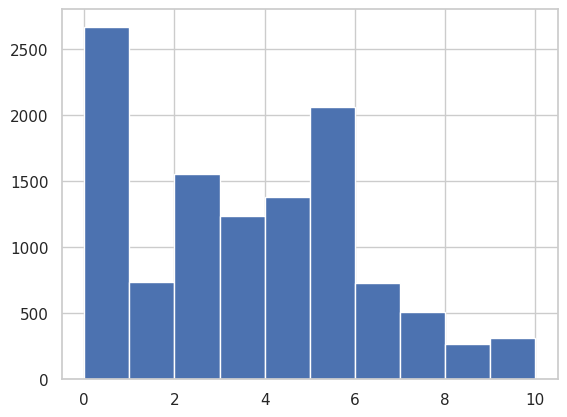

In [13]:
print(f"{df['rank_da_pagina'].value_counts()}\n\n")
df['rank_da_pagina'].hist()

#Com essa análise podemos observar que a maioria dos sites possuem um ranqueamento baixo, mas isso não classifica um phishing ou não

trafego_web
0          4444
5707171     176
12          163
1           148
5697976      91
           ... 
9169065       1
26630         1
1490065       1
2299843       1
1677903       1
Name: count, Length: 4744, dtype: int64




<Axes: >

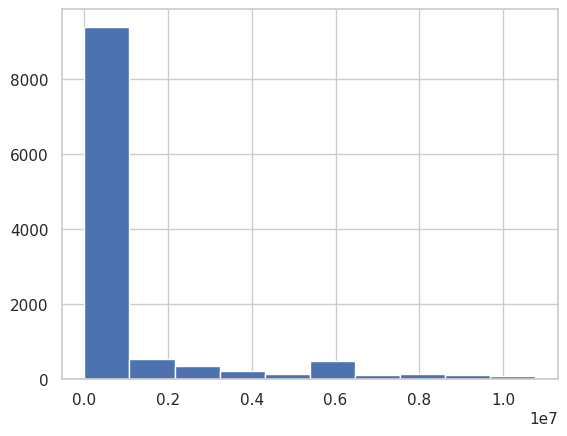

In [14]:
print(f"{df['trafego_web'].value_counts()}\n\n")
df['trafego_web'].hist()

#Com essa análise podemos observar que uma boa parte dos sites não possuem trafego de usuários, podemos investigar se todos esses são pishing ou temos sites legítimos sem fluxo

indicadores_phishing
0     9389
1     1079
2      460
3      325
4      136
5       28
6        9
10       2
7        2
Name: count, dtype: int64




<Axes: >

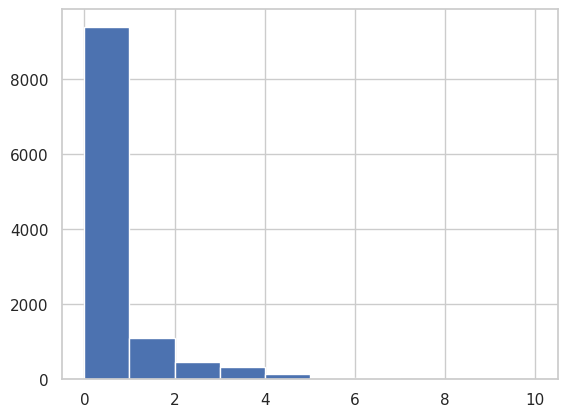

In [15]:
print(f"{df['indicadores_phishing'].value_counts()}\n\n")
df['indicadores_phishing'].hist()

#Com essa análise podemos observar mais de 9k links não possuem indicadores de phishing, contudo sabemos que metade do dataset são links de phishing.
#Isso mostra uma certa ineficácia da feature para classificar o status dos sites

quantidade_palavra_www
0    6330
1    5074
2      26
Name: count, dtype: int64




<Axes: >

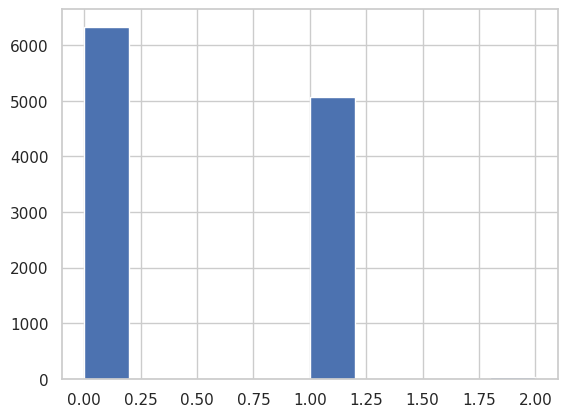

In [16]:
print(f"{df['quantidade_palavra_www'].value_counts()}\n\n")
df['quantidade_palavra_www'].hist()

#Com essa análise podemos observar que não é obrigatório existir o termo 'www' em uma url e que pouquissimos possuem mais de 1 (quase certeza que esses 26 casos são de phishing)

http_no_caminho
0    11280
1      129
2       10
4        9
3        2
Name: count, dtype: int64




<Axes: >

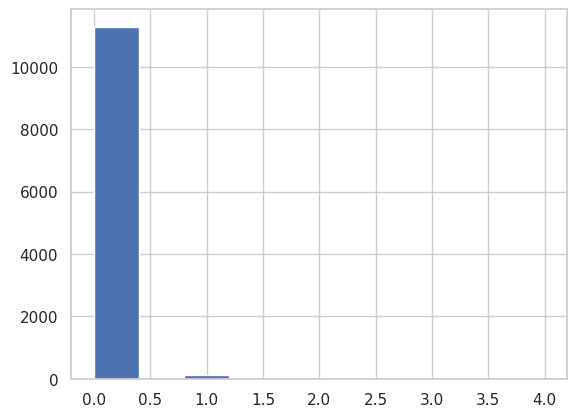

In [17]:
print(f"{df['http_no_caminho'].value_counts()}\n\n")
df['http_no_caminho'].hist()

#Com essa análise podemos observar um comportamento parecido com a feature anterior ('www')
#Temos mais casos no qual a url possui mais de um 'http' chegando a quatro em um mesmo link (acontecendo em nove links diferentes)

possui_iframe
0    11415
1       15
Name: count, dtype: int64




<Axes: >

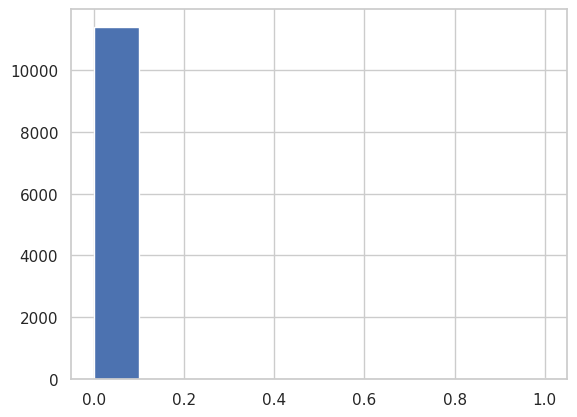

In [18]:
print(f"{df['possui_iframe'].value_counts()}\n\n")
df['possui_iframe'].hist()

#No caso de possuir iframe, temos apenas 15 links com iframe. Devido a isso, torna-se uma feature menos importante para classificação

possui_popup
0    11361
1       69
Name: count, dtype: int64




<Axes: >

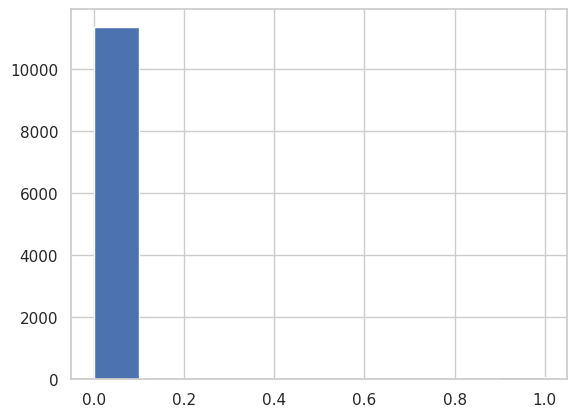

In [19]:
print(f"{df['possui_popup'].value_counts()}\n\n")
df['possui_popup'].hist()

#No caso de possuir popup, temos apenas 15 links com popup. Devido a isso, torna-se uma feature menos importante para classificação

#### 1.4 Qual a porcentagem de nulos?

In [20]:
df.isnull().sum()

,0
url,0
tamanho_url,0
tamanho_hostname,0
endereco_ip,0
quantidade_pontos(.),0
...,...
trafego_web,0
possui_registro_dns,0
indexado_google,0
rank_da_pagina,0


#### 1.5 Temos dados duplicados?


In [21]:
# Não temos dados duplicados no dataset
df.duplicated().sum()

np.int64(0)

In [22]:
# Como não temos dados duplicados o dataframe duplicados está vazio

df_duplicados = df[df.duplicated(keep=False)]
df_duplicados

,url,tamanho_url,tamanho_hostname,endereco_ip,quantidade_pontos(.),quantidade_hifens(-),quantidade_arrobas(@),quantidade_interrogacoes(?),quantidade_e_comercial(&),quantidade_ou(\),...,dominio_no_titulo,dominio_no_copyright,dominio_registrado_whois,tempo_registro_dominio,idade_dominio,trafego_web,possui_registro_dns,indexado_google,rank_da_pagina,classificacao


#### 1.7. Qual a média, desvio padrão e amplitude das colunas numéricas?

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   url                                    11430 non-null  object 
 1   tamanho_url                            11430 non-null  int64  
 2   tamanho_hostname                       11430 non-null  int64  
 3   endereco_ip                            11430 non-null  int64  
 4   quantidade_pontos(.)                   11430 non-null  int64  
 5   quantidade_hifens(-)                   11430 non-null  int64  
 6   quantidade_arrobas(@)                  11430 non-null  int64  
 7   quantidade_interrogacoes(?)            11430 non-null  int64  
 8   quantidade_e_comercial(&)              11430 non-null  int64  
 9   quantidade_ou(\)                       11430 non-null  int64  
 10  quantidade_igual(=)                    11430 non-null  int64  
 11  qu

In [24]:
df.describe()

,tamanho_url,tamanho_hostname,endereco_ip,quantidade_pontos(.),quantidade_hifens(-),quantidade_arrobas(@),quantidade_interrogacoes(?),quantidade_e_comercial(&),quantidade_ou(\),quantidade_igual(=),...,titulo_vazio,dominio_no_titulo,dominio_no_copyright,dominio_registrado_whois,tempo_registro_dominio,idade_dominio,trafego_web,possui_registro_dns,indexado_google,rank_da_pagina
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,0.998317,...,0.330460,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000


In [25]:
#Criando uma tabela personalizada de estatística do dataset
estatistica = pd.DataFrame({
    'Média':df.mean(numeric_only=True),
    'Desvio Padrão':df.std(numeric_only=True),
    'Mínimo':df.min(numeric_only=True),
    'Máximo':df.max(numeric_only=True)
})

estatistica['Amplitude'] = (
    estatistica['Máximo']-
    estatistica['Mínimo']
)

estatistica

,Média,Desvio Padrão,Mínimo,Máximo,Amplitude
tamanho_url,61.126684,5.529732e+01,12.0,1641.0,1629.0
tamanho_hostname,21.090289,1.077717e+01,4.0,214.0,210.0
endereco_ip,0.150569,3.576436e-01,0.0,1.0,1.0
quantidade_pontos(.),2.480752,1.369686e+00,1.0,24.0,23.0
quantidade_hifens(-),0.997550,2.087087e+00,0.0,43.0,43.0
...,...,...,...,...,...
idade_dominio,4062.543745,3.107785e+03,-12.0,12874.0,12886.0
trafego_web,856756.643307,1.995606e+06,0.0,10767986.0,10767986.0
possui_registro_dns,0.020122,1.404254e-01,0.0,1.0,1.0
indexado_google,0.533946,4.988682e-01,0.0,1.0,1.0


#### 1.8 Análise Univariada

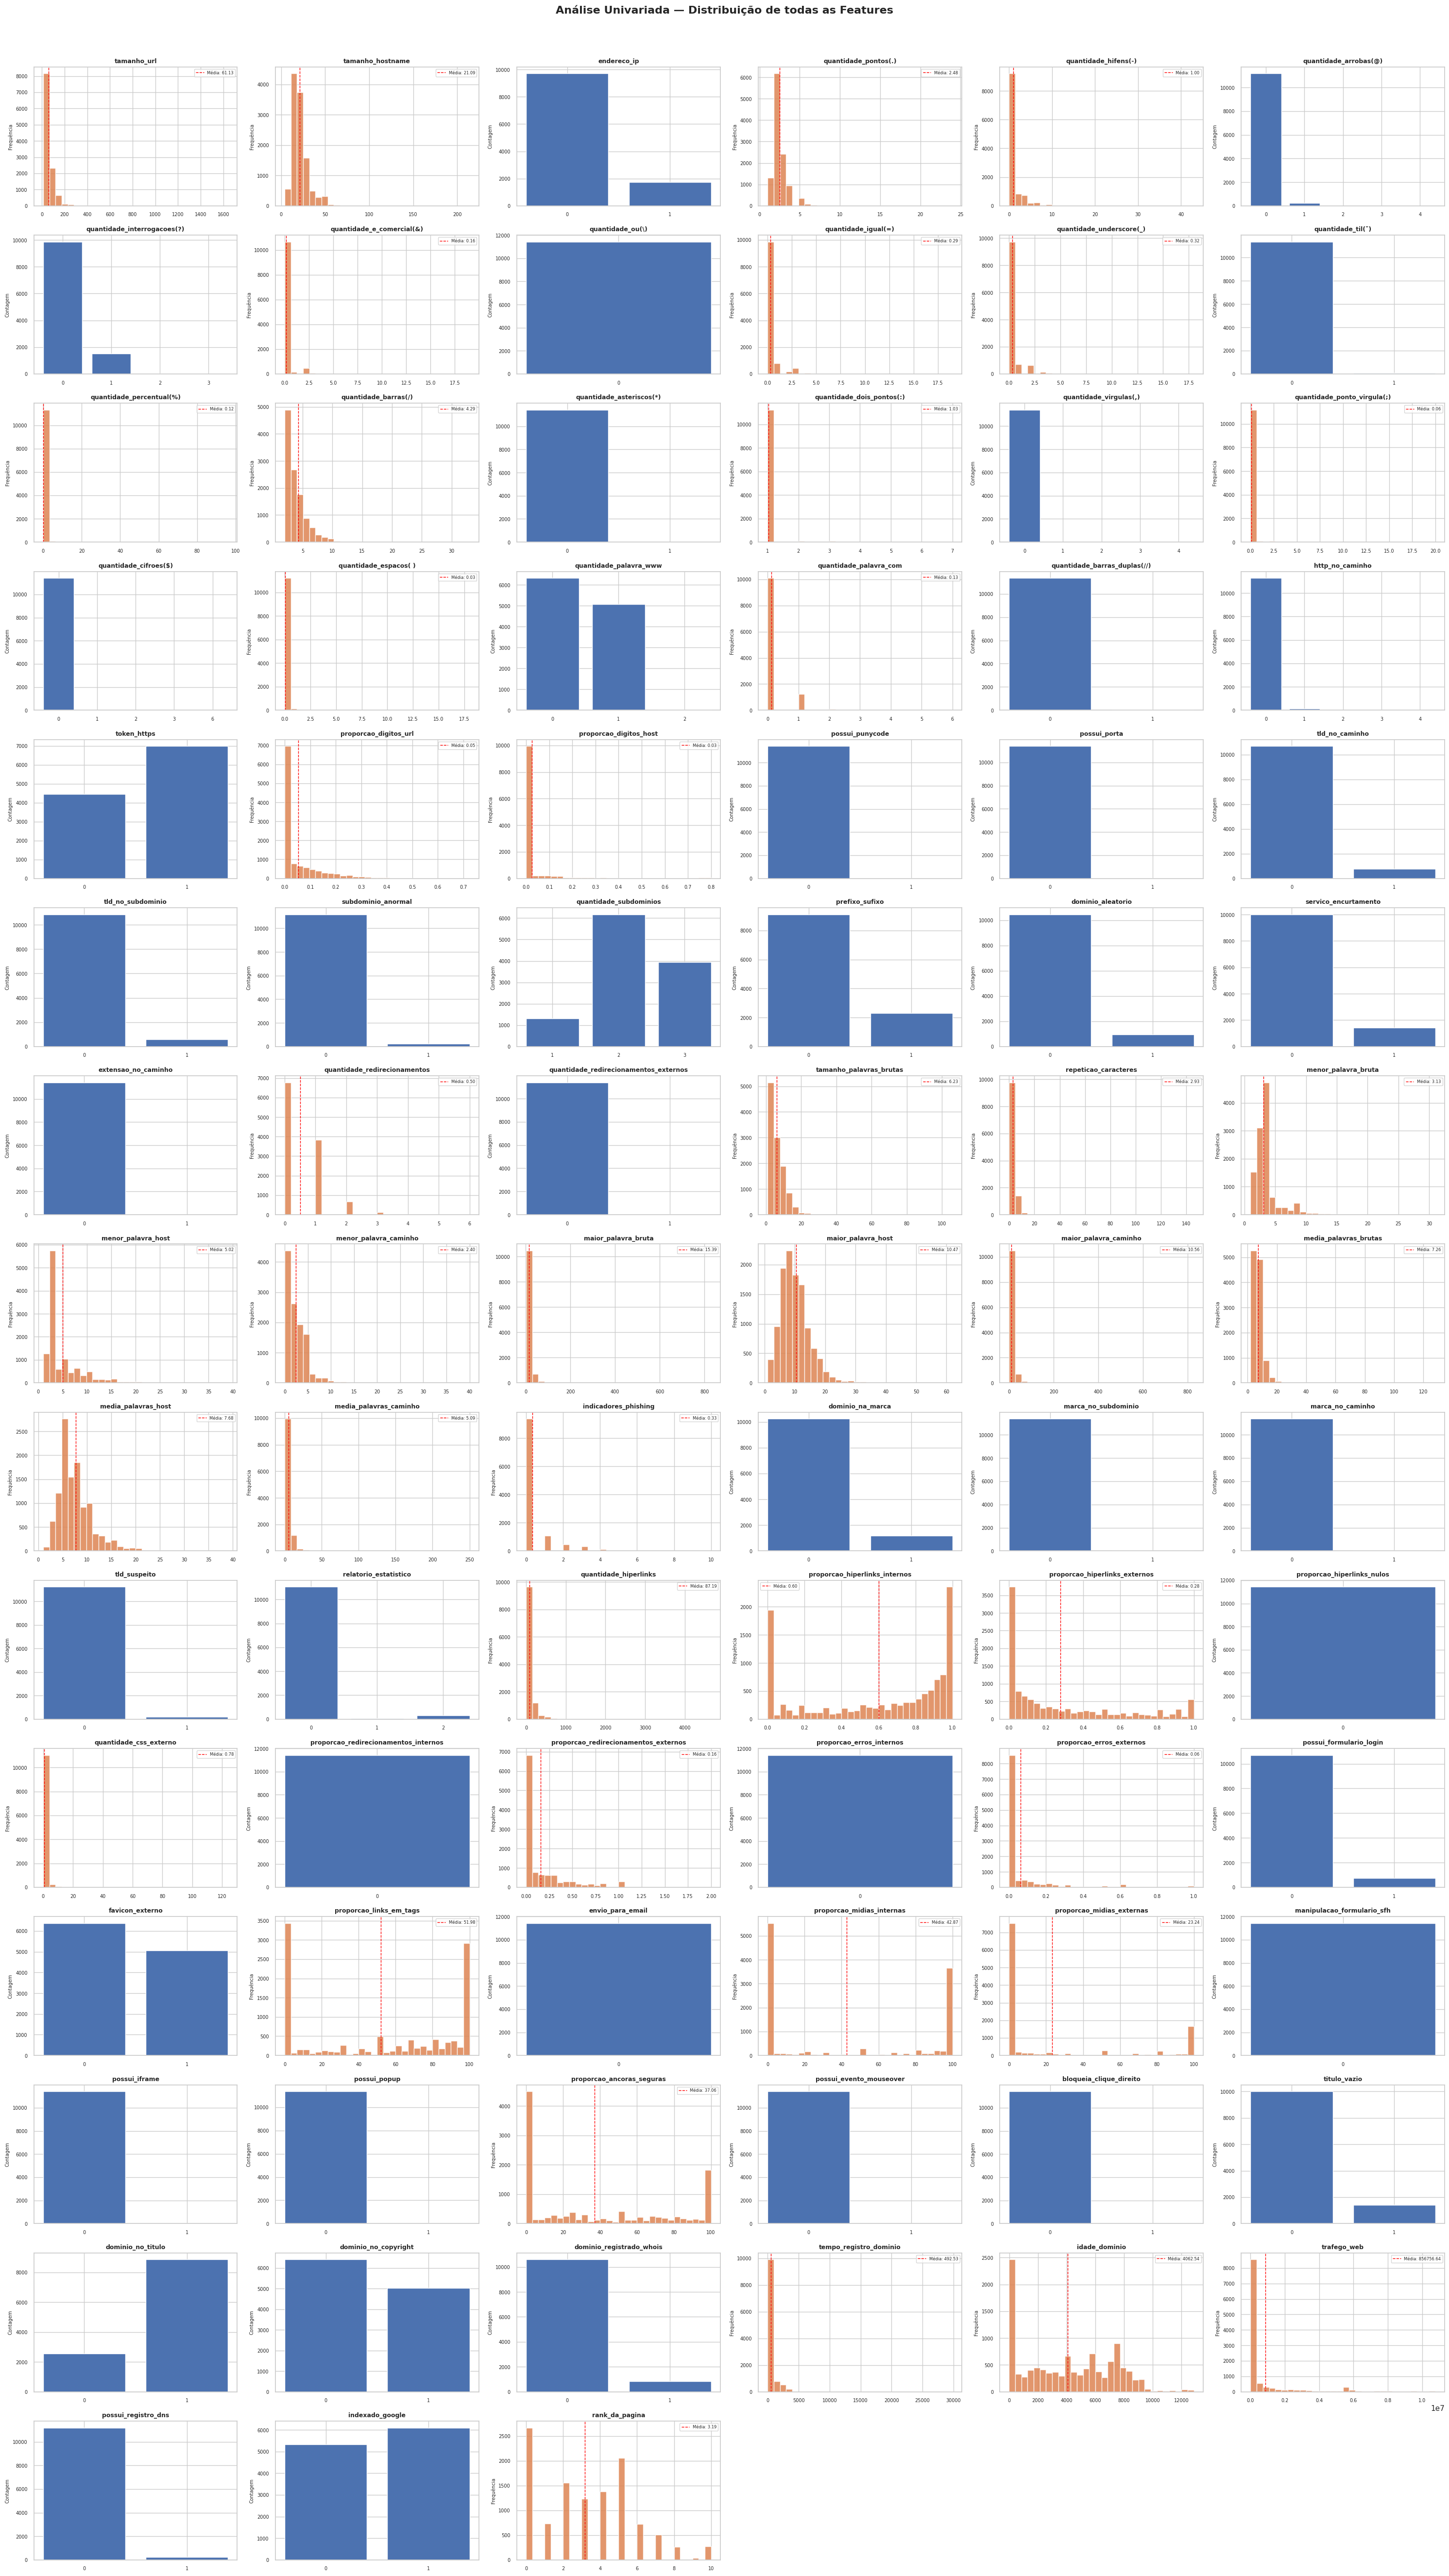

Total de features plotadas: 87


In [26]:
# Selecionamos apenas colunas numéricas (excluindo 'url' e 'status')
colunas_numericas = df.select_dtypes(include='number').columns.tolist()

colunas_por_linha = 6
n_linhas = -(-len(colunas_numericas) // colunas_por_linha)

fig, axes = plt.subplots(
    nrows=n_linhas,
    ncols=colunas_por_linha,
    figsize=(5 * colunas_por_linha, 3.5 * n_linhas)
)

axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    ax = axes[i]

    valores_unicos = df[col].nunique()

    if valores_unicos <= 5:
        contagem = df[col].value_counts().sort_index()
        ax.bar(contagem.index.astype(str), contagem.values, color='#4C72B0', edgecolor='white')
        ax.set_title(col, fontsize=9, fontweight='bold')
        ax.set_ylabel('Contagem', fontsize=7)
    else:
        ax.hist(df[col].dropna(), bins=30, color='#DD8452', edgecolor='white', alpha=0.85)
        ax.set_title(col, fontsize=9, fontweight='bold')
        ax.set_ylabel('Frequência', fontsize=7)

        media = df[col].mean()
        ax.axvline(media, color='red', linestyle='--', linewidth=1,
                   label=f'Média: {media:.2f}')
        ax.legend(fontsize=6)

    ax.tick_params(axis='both', labelsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Análise Univariada — Distribuição de todas as Features',
             fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas_univariada.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total de features plotadas: {len(colunas_numericas)}")

<Axes: >

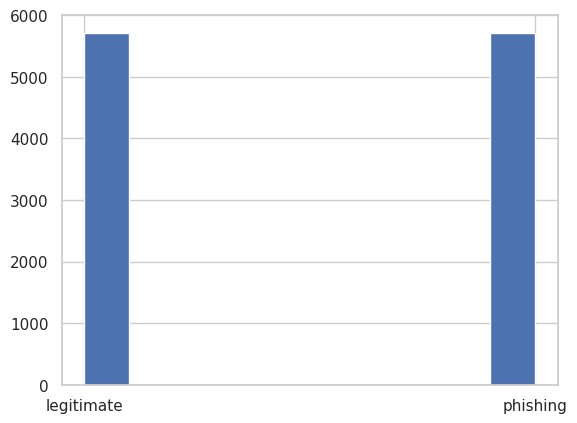

In [27]:
# Criando o Histograma da classe target 'status'
df['classificacao'].hist()

In [28]:
#Valores de status de phishing e legitimate no target
df['classificacao'].value_counts()

,count
classificacao,
legitimate,5715
phishing,5715


In [29]:
#Transformando esses valores em porcentagem (proporção)
df['classificacao'].value_counts(normalize=True)

,proportion
classificacao,
legitimate,0.5
phishing,0.5


<Axes: xlabel='classificacao', ylabel='proportion'>

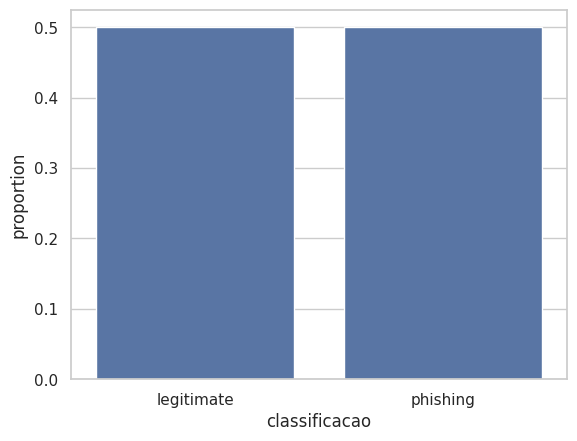

In [30]:
#Plotando isso em um gráfico de barplot para termos uma noção do balanceamento do target
#Como analisamos o target do dataset está totalmente balanceado
df_status = df['classificacao'].value_counts(normalize=True)

sns.barplot(data=df_status)

#### 1.9. Análise Bivariada (Relação de todas as métricas com nosso target 'Status'

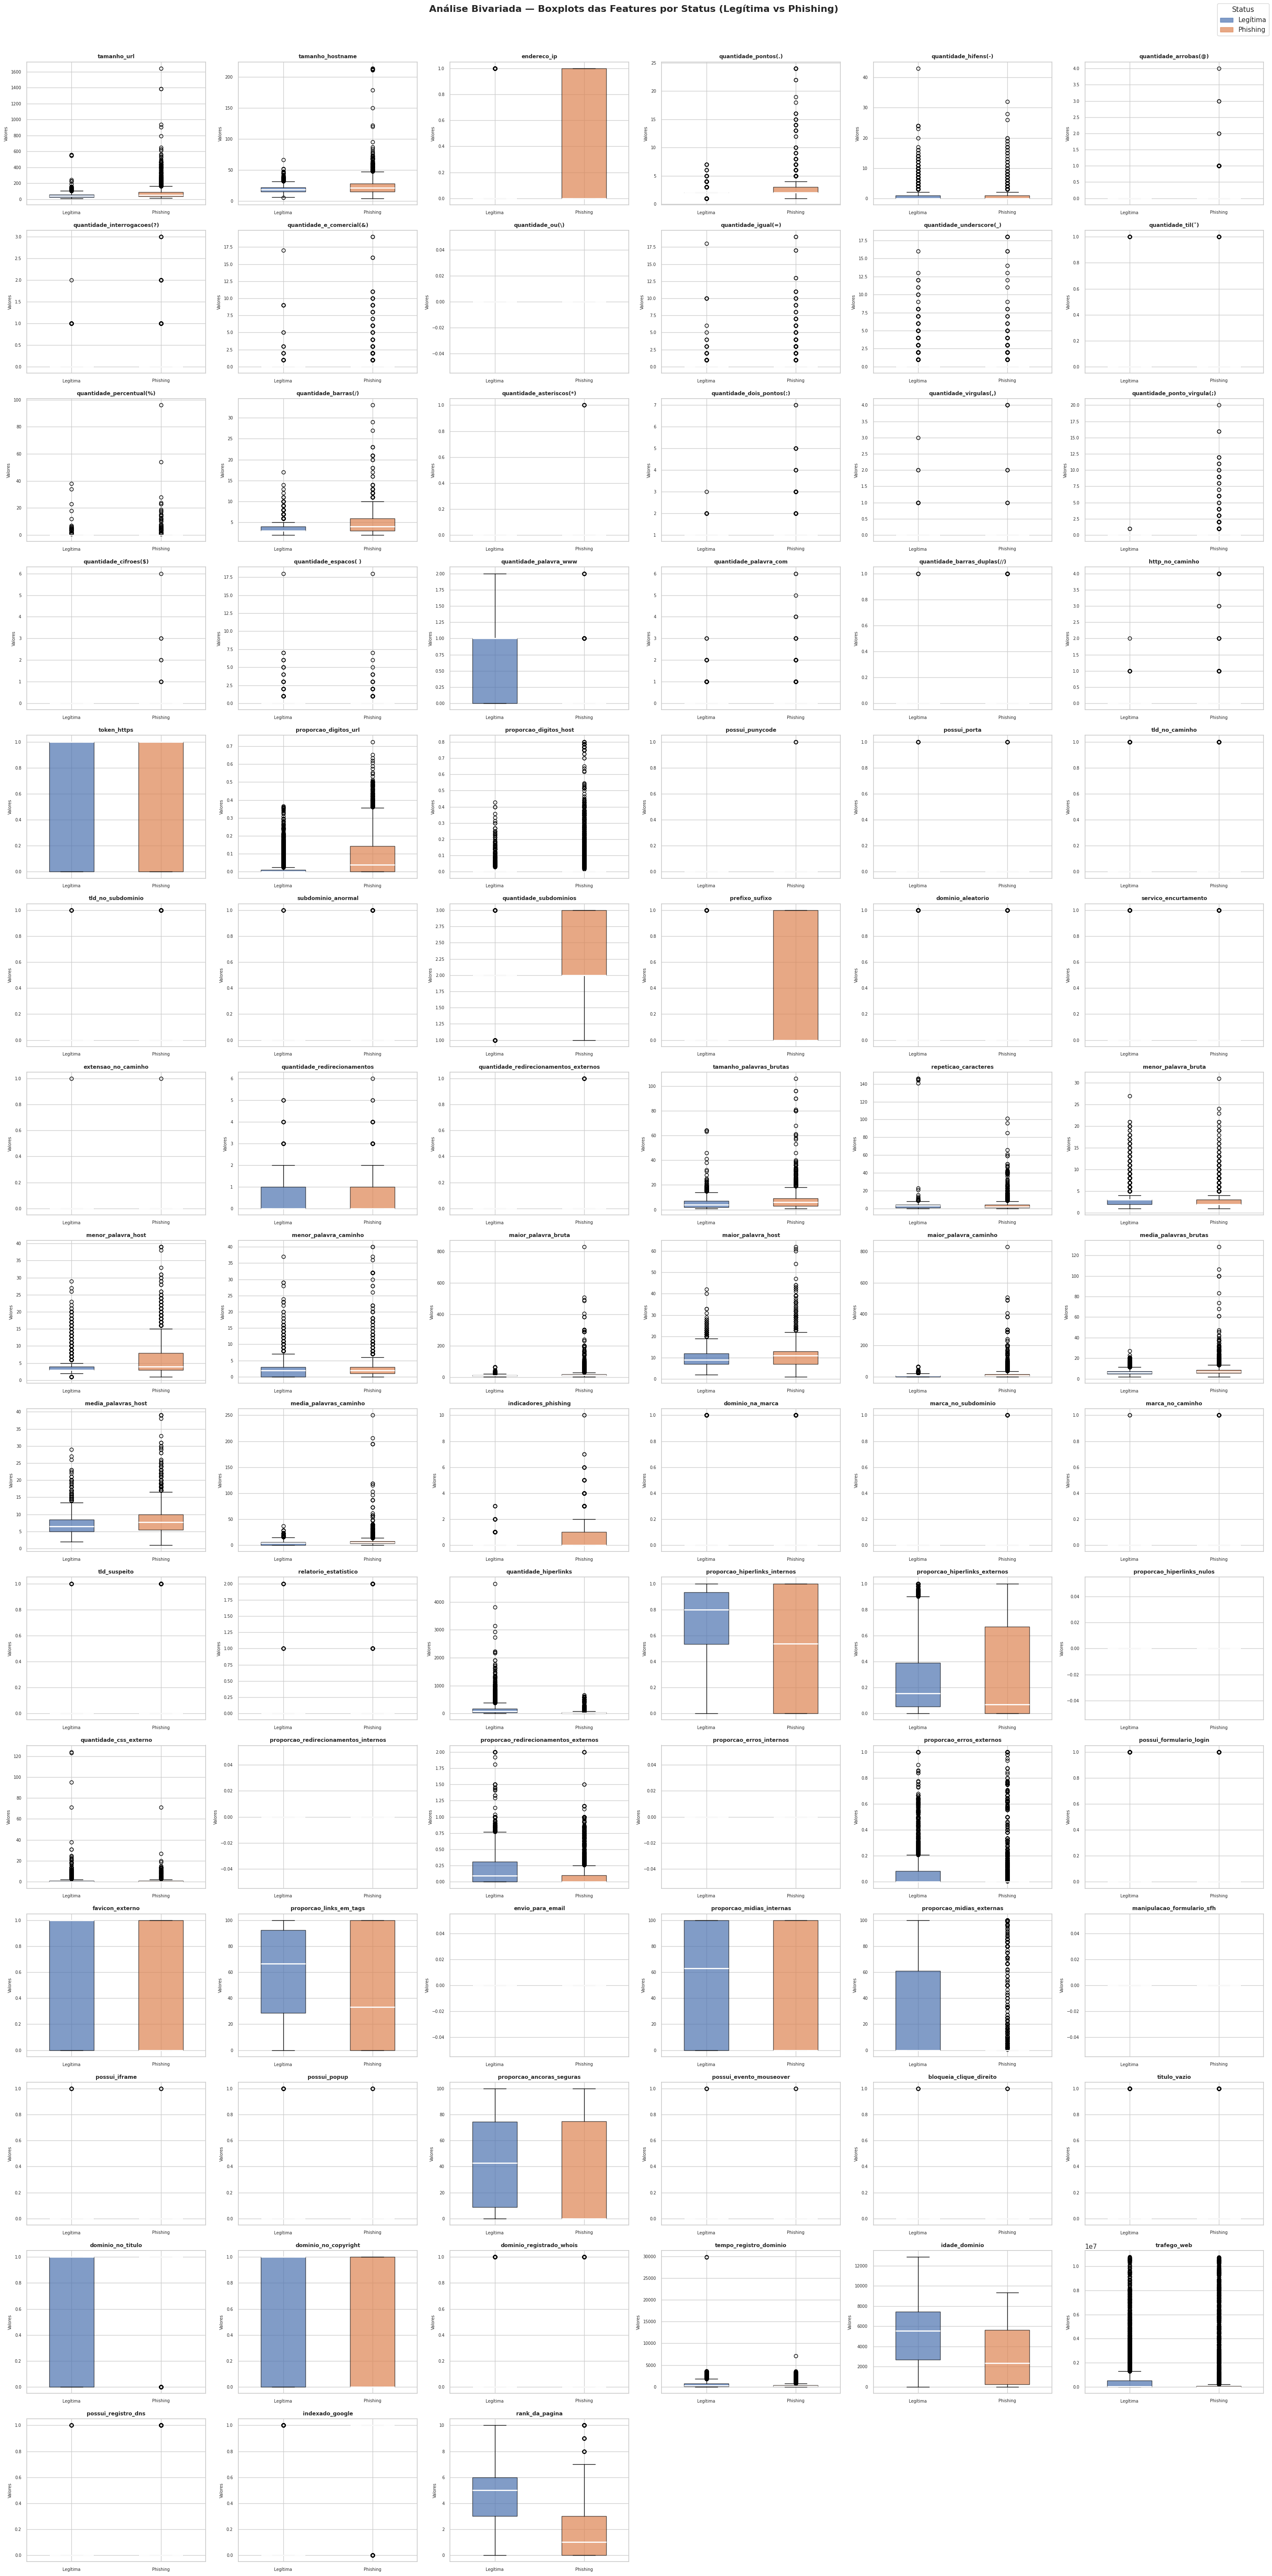

Total de features plotadas: 87


In [31]:
#Boxplots de todas as features x target 'classificação'
# Visualizar como a distribuição de cada feature se comporta para URLs legítimas vs phishing

# Seleciona apenas colunas numéricas (exclui 'url' e 'classificação')
colunas_numericas = df.select_dtypes(include='number').columns.tolist()

# Separando os dados por classe do target
legitimas = df[df['classificacao'] == 'legitimate']
phishing  = df[df['classificacao'] == 'phishing']

colunas_por_linha = 6
n_linhas = -(-len(colunas_numericas) // colunas_por_linha)

fig, axes = plt.subplots(
    nrows=n_linhas,
    ncols=colunas_por_linha,
    figsize=(5 * colunas_por_linha, 4 * n_linhas)
)

axes = axes.flatten()

cores  = ['#4C72B0', '#DD8452']
labels = ['Legítima', 'Phishing']

for i, col in enumerate(colunas_numericas):
    ax = axes[i]

    # Monta os dois grupos para o boxplot lado a lado
    dados = [
        legitimas[col].dropna().values,
        phishing[col].dropna().values
    ]

    bp = ax.boxplot(
        dados,
        patch_artist=True,
        labels=labels,
        widths=0.5
    )

    # Colorindo cada caixa com a cor da classe
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    # Colorindo medianas em branco para destacar
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)

    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Valores', fontsize=7)
    ax.tick_params(axis='both', labelsize=7)

# Remove subplots vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Legenda global no topo
legend_patches = [
    plt.matplotlib.patches.Patch(color=cores[0], alpha=0.7, label='Legítima'),
    plt.matplotlib.patches.Patch(color=cores[1], alpha=0.7, label='Phishing')
]
fig.legend(handles=legend_patches, loc='upper right',
           fontsize=11, title='Status', title_fontsize=12)

plt.suptitle('Análise Bivariada — Boxplots das Features por Status (Legítima vs Phishing)',
             fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_bivariada.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total de features plotadas: {len(colunas_numericas)}")

##### Primeira pergunta




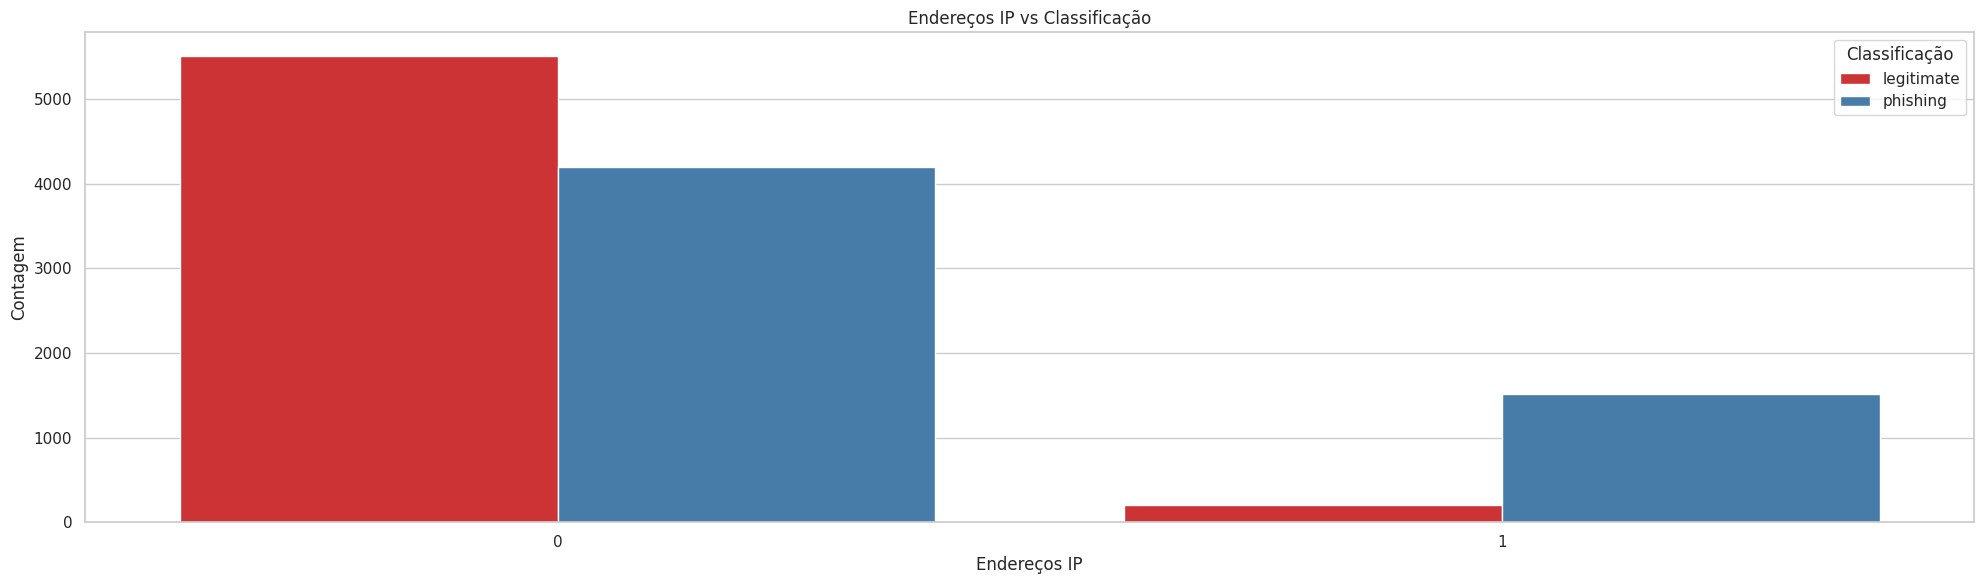

In [32]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='endereco_ip',
    hue='classificacao',
    palette='Set1'
)

plt.title('Endereços IP vs Classificação')
plt.xlabel('Endereços IP')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Esse gráfico nos mostra que URLs que não contenham endereço ip no domínio tem uma boa distribuição entre 'legitimate' e 'phishing', sendo a maior parte URLs legítimas, porém, URLs que contenham endereço ip no domínio foram classificados como 'phishing' em sua maioria esmagadora.

##### Segunda pergunta

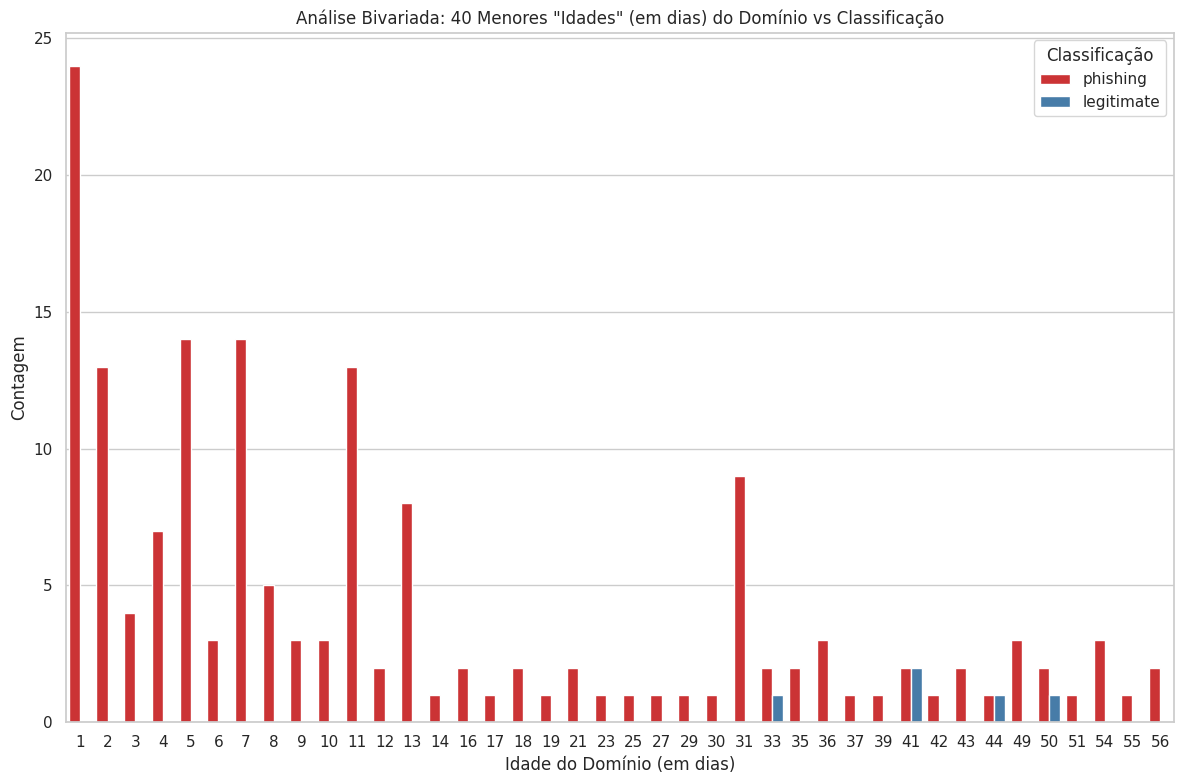

In [33]:
idades_validas = df[df['idade_dominio'] > 0]['idade_dominio'].unique()
idades_mais_novas = sorted(idades_validas)[:40]

df_filtrado = df[df['idade_dominio'].isin(idades_mais_novas)]

#idades_mais_novas = sorted(df['idade_dominio'].unique())[:5]
#df_filtrado = df[df['idade_dominio'].isin(idades_mais_novas)]

plt.figure(figsize=(12, 8))

sns.countplot(
    data=df_filtrado,
    x='idade_dominio',
    hue='classificacao',
    order=idades_mais_novas,
    palette='Set1'
)

plt.title('Análise Bivariada: 40 Menores "Idades" (em dias) do Domínio vs Classificação')
plt.xlabel('Idade do Domínio (em dias)')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Esse gráfico nos mostra que URLs mais "novas" tem grandes chances de serem phishing, começando a aparecer URLs legítimas apenas com 33 dias de publicação, porém ainda em pequenas quantidades.

##### Terceira pergunta

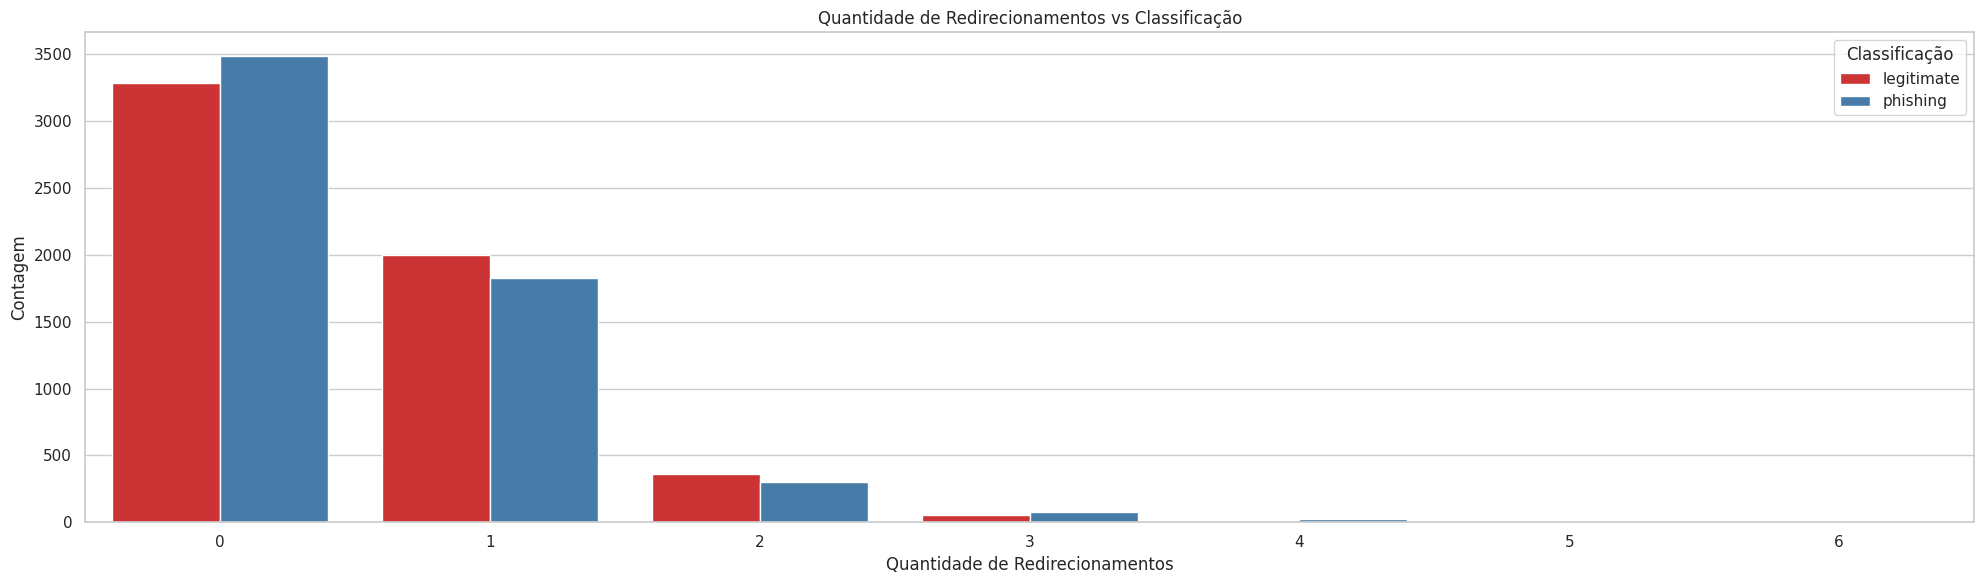

In [34]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='quantidade_redirecionamentos',
    hue='classificacao',
    palette='Set1'
)

plt.title('Quantidade de Redirecionamentos vs Classificação')
plt.xlabel('Quantidade de Redirecionamentos')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Esse gráfico nos mostra que as URLs apresentam um comportamento parecido, onde as variáveis target 'legitimate' e 'phishing' aparecem bem balanceadas dentro de cada quantidade de redirecionamentos, o que significa que apenas essa feature em si não é suficiente para dizer que uma URL é legítima ou não.

##### Quarta pergunta

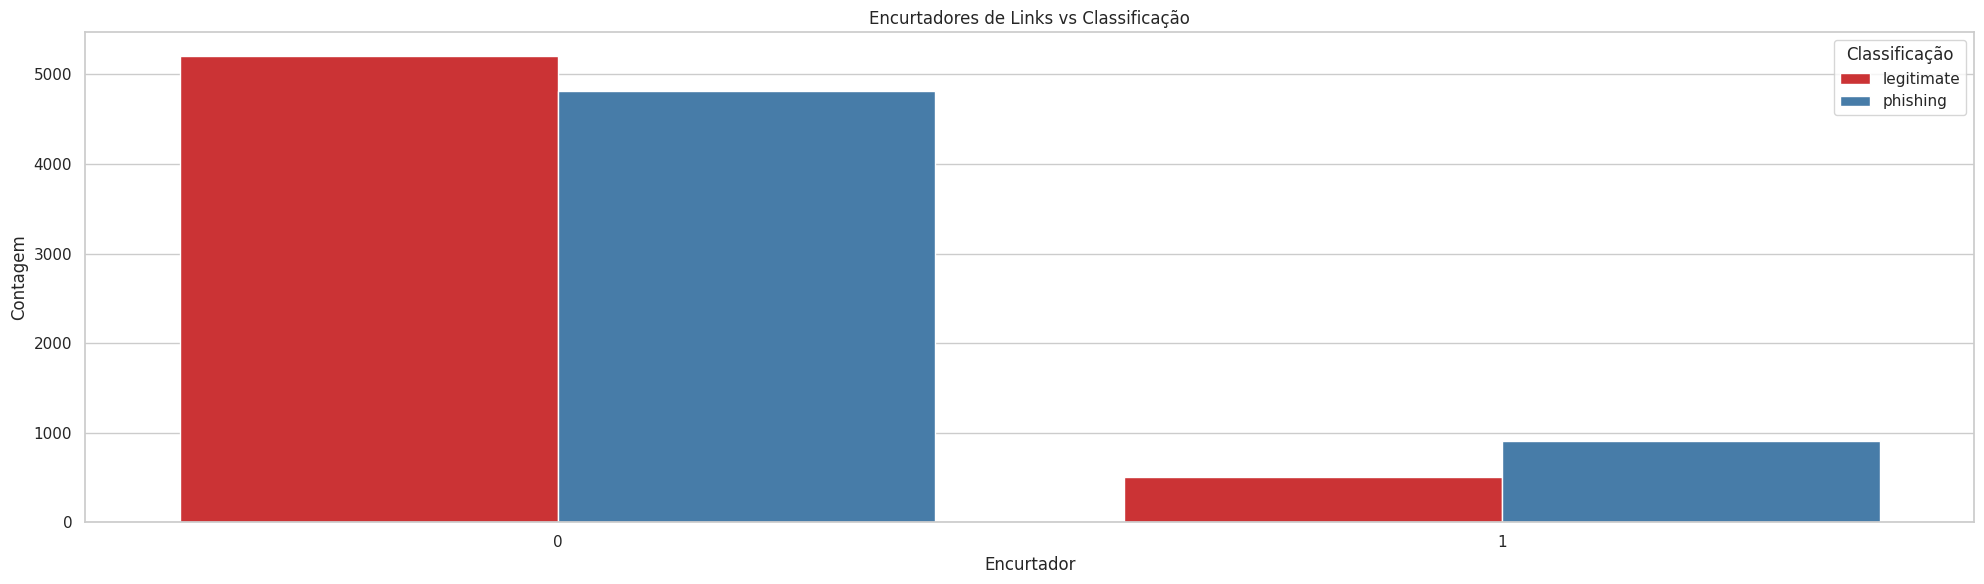

In [35]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='servico_encurtamento',
    hue='classificacao',
    palette='Set1'
)

plt.title('Encurtadores de Links vs Classificação')
plt.xlabel('Encurtador')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Esse gráfico também nos mostra um balanceamento entre a classificação das variáveis target, porém, URLs que contenham algum serviço de encurtadores de links tendem a ser mais maliciosos.

##### Quinta pergunta

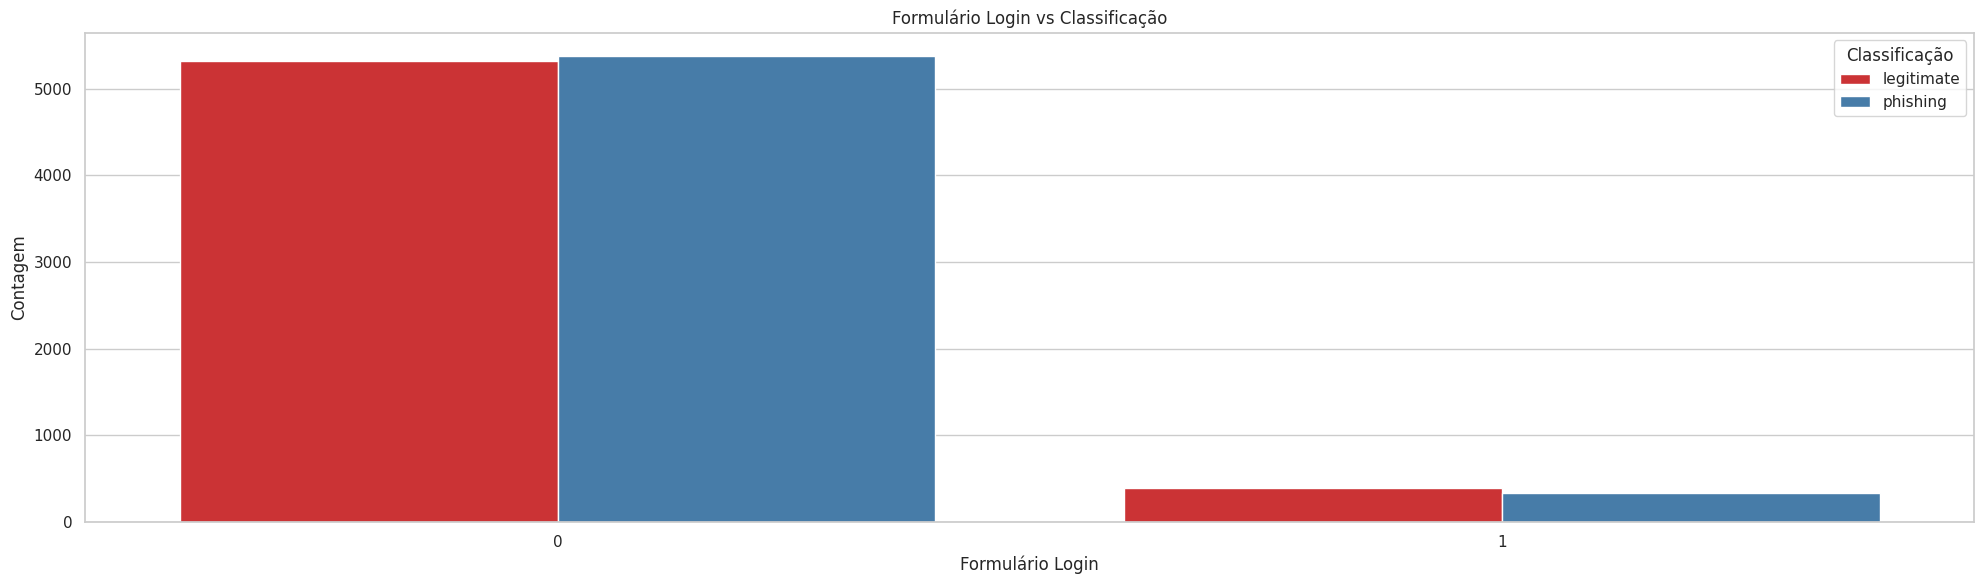

In [36]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='possui_formulario_login',
    hue='classificacao',
    palette='Set1'
)

plt.title('Formulário Login vs Classificação')
plt.xlabel('Formulário Login')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Esse gráfico também nos mostra um balanceamento claro entre a classificação das variáveis target, o que nos mostra que essa variável não apresenta uma importância tão grande para saber se tem a chance de uma URL ser phishing.

##### Sexta pergunta

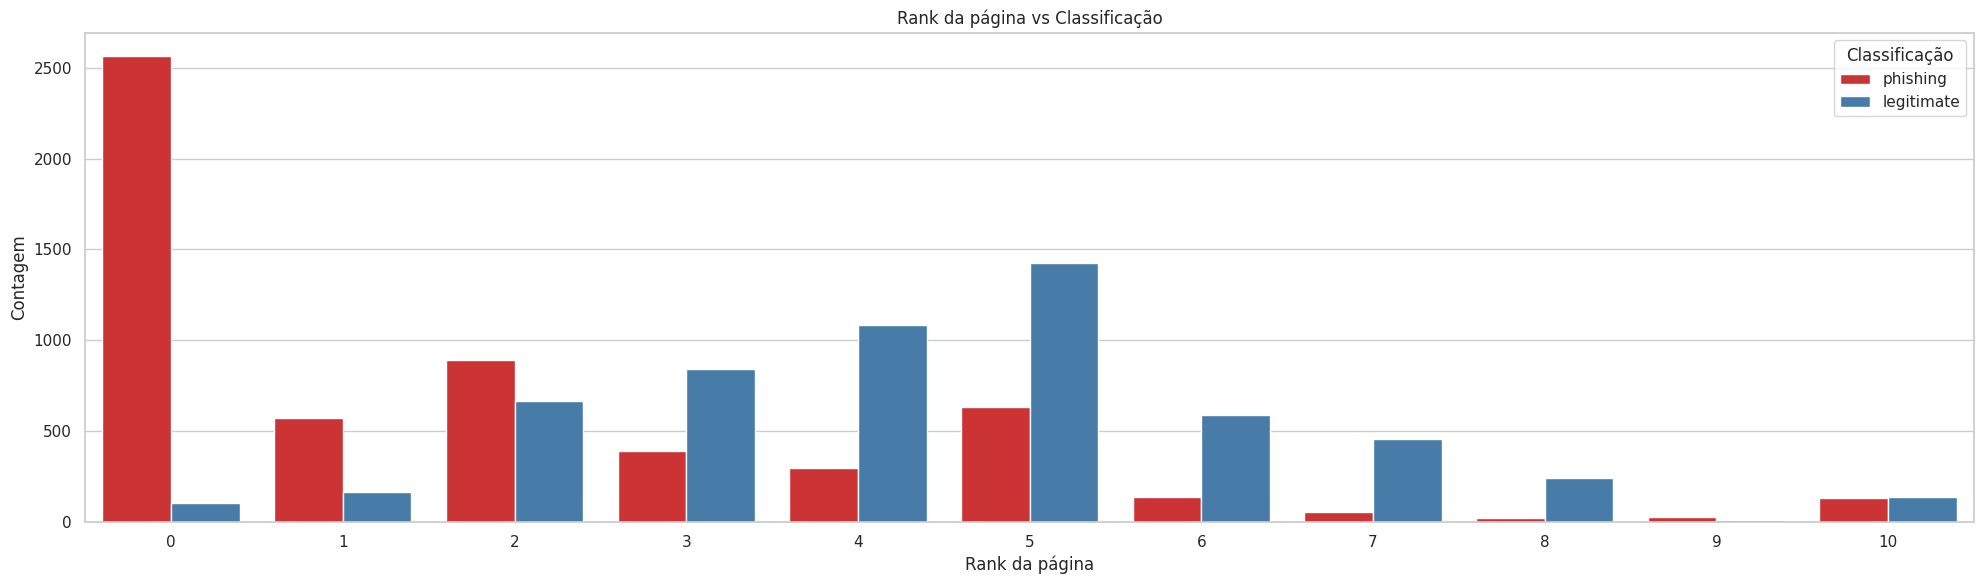

In [37]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='rank_da_pagina',
    hue='classificacao',
    palette='Set1'
)

plt.title('Rank da página vs Classificação')
plt.xlabel('Rank da página')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Analisando o ranqueamento das páginas, notamos que sites com ranqueamento zero (0) possuem uma volumetria esmagadora de classificação phishing, e isso ocorre para números baixos de 1 e 2.

A partir do ranqueamento 3 que a maioria das páginas são legítimas. Uma ressalva para a nota 10 que possui quase uma pariedade entre urls de phishing e legitimate.

##### Sétima pergunta

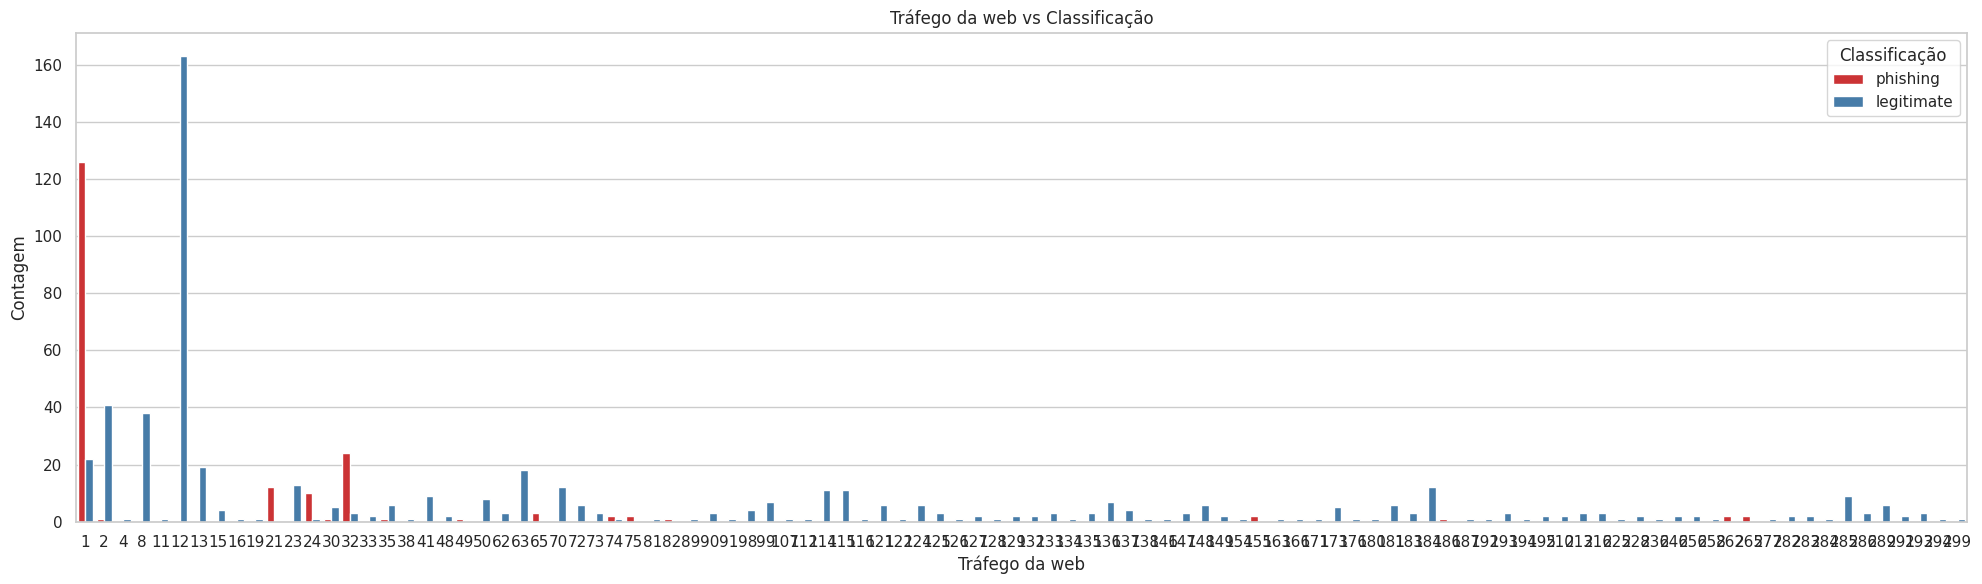

In [38]:
trafego_cresc = df[df['trafego_web'] > 0]['trafego_web'].unique()
trafego_filtrado_cresc = sorted(trafego_cresc)[:100]

df_trafego_cresc = df[df['trafego_web'].isin(trafego_filtrado_cresc)]

plt.figure(figsize=(20, 6))

sns.countplot(
    data=df_trafego_cresc,
    x='trafego_web',
    hue='classificacao',
    palette='Set1'
)

plt.title('Tráfego da web vs Classificação')
plt.xlabel('Tráfego da web')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

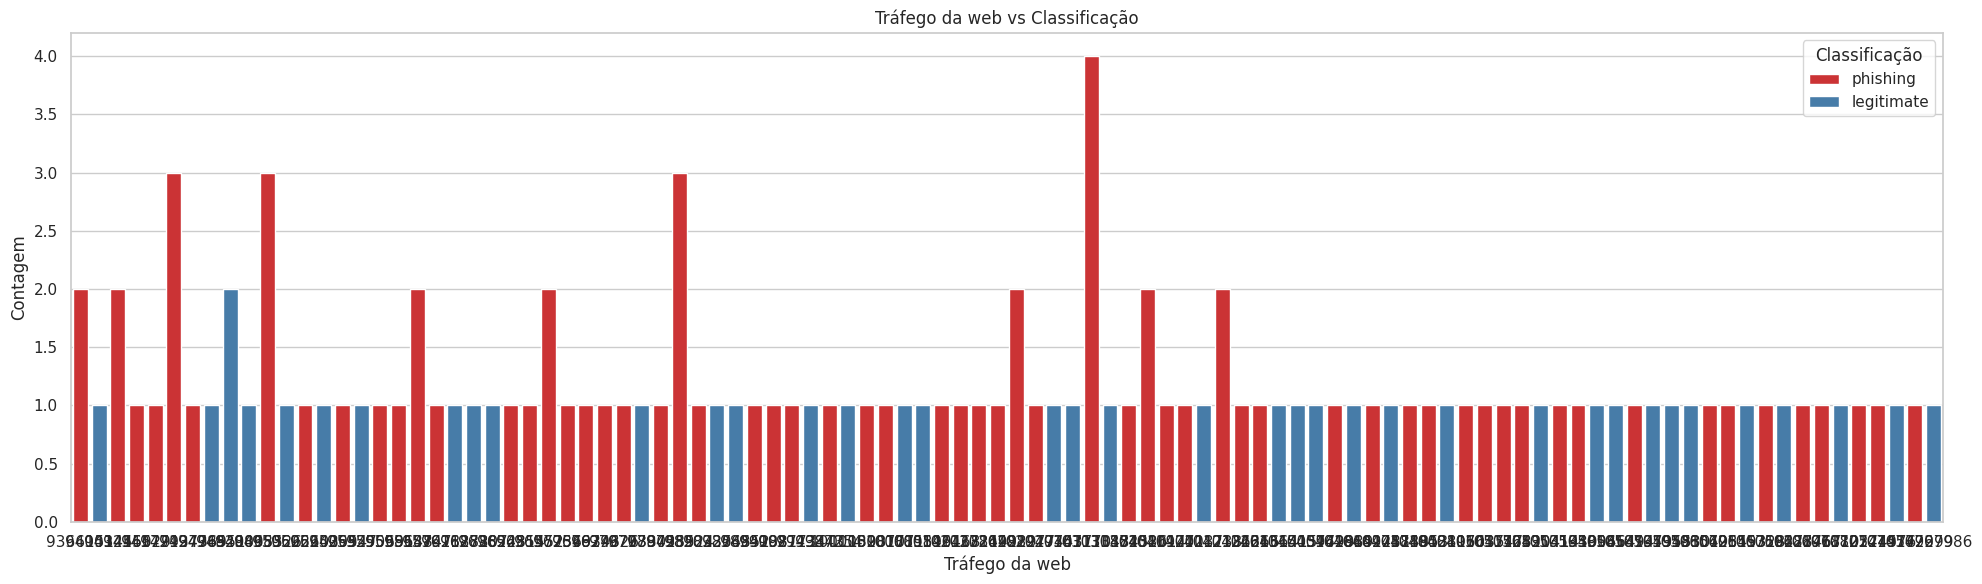

In [39]:
trafego_desc = df[df['trafego_web'] > 0]['trafego_web'].unique()
trafego_filtrado_desc = sorted(trafego_desc, reverse=True)[:100]

df_trafego_desc = df[df['trafego_web'].isin(trafego_filtrado_desc)]

plt.figure(figsize=(20, 6))

sns.countplot(
    data=df_trafego_desc,
    x='trafego_web',
    hue='classificacao',
    palette='Set1'
)

plt.title('Tráfego da web vs Classificação')
plt.xlabel('Tráfego da web')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Analisando os dois gráficos, vimos um comportamento diferente do que esperavamos. URLs com tráfego baixo possuiam em sua maioria classificação 'legitimate'.

Enquanto, no segundo gráfico, que filtra os 100 maiores tráfegos da web para as urls do dataset. Notamos uma ligeira maioria para classificação de phishing.

##### Oitava pergunta

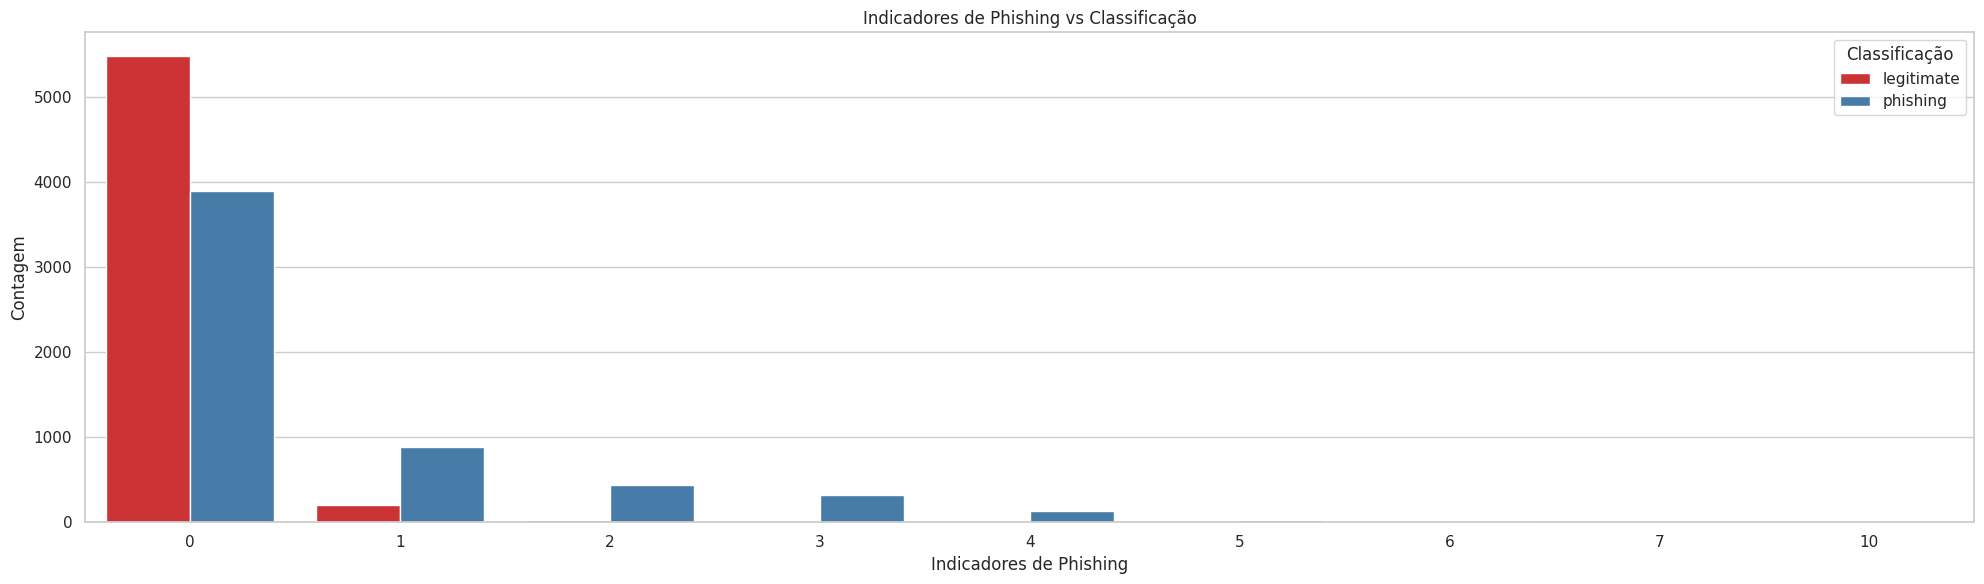

In [40]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='indicadores_phishing',
    hue='classificacao',
    palette='Set1'
)

plt.title('Indicadores de Phishing vs Classificação')
plt.xlabel('Indicadores de Phishing')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Para essa feature não encontramos uma boa importância pois a contagem esmagadora de linhas foi para o valor de 0 indicadores de phishing para as urls. Além disso, Temos um numero alto de páginas de phishing sem nenhum indicador.

#### Nona pergunta

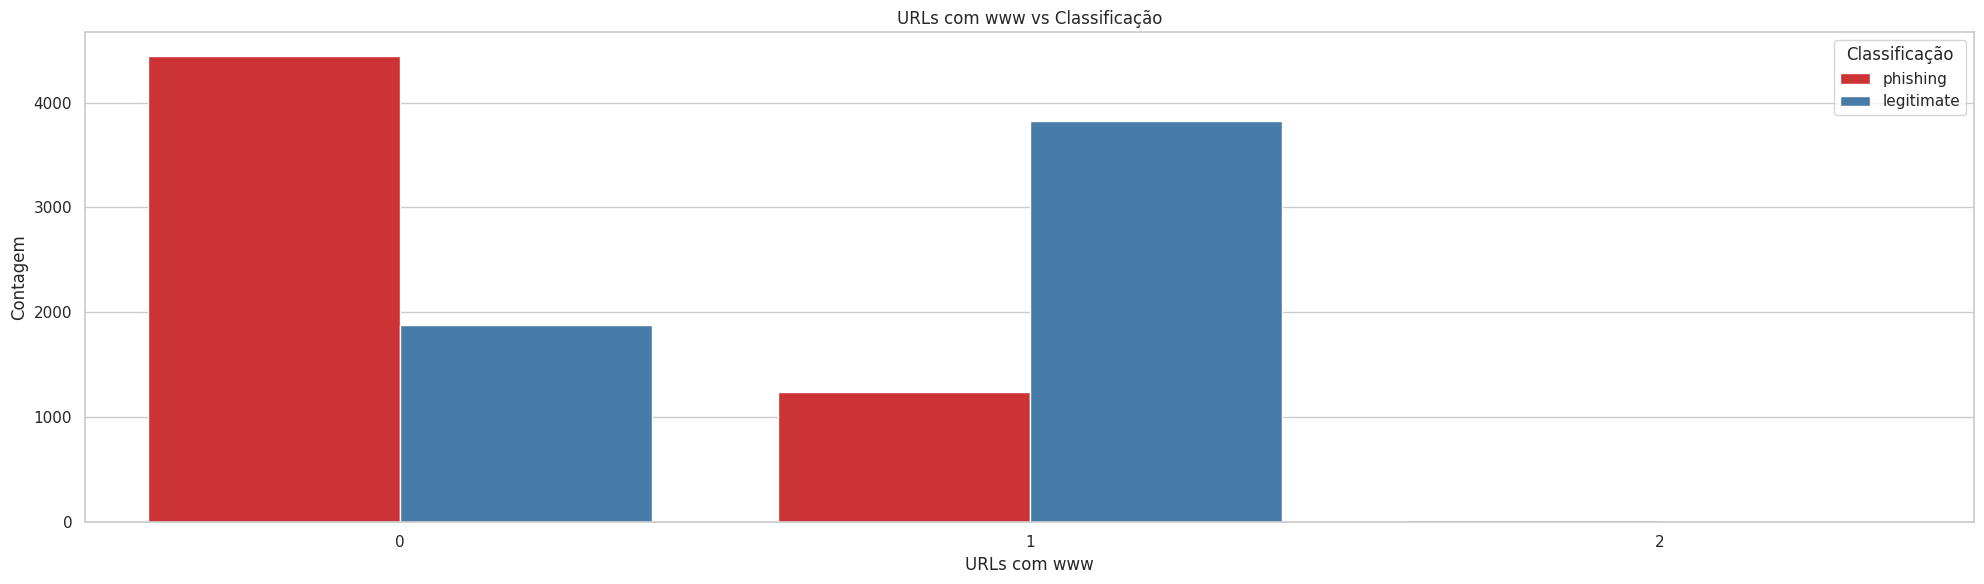

In [41]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='quantidade_palavra_www',
    hue='classificacao',
    palette='Set1'
)

plt.title('URLs com www vs Classificação')
plt.xlabel('URLs com www')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

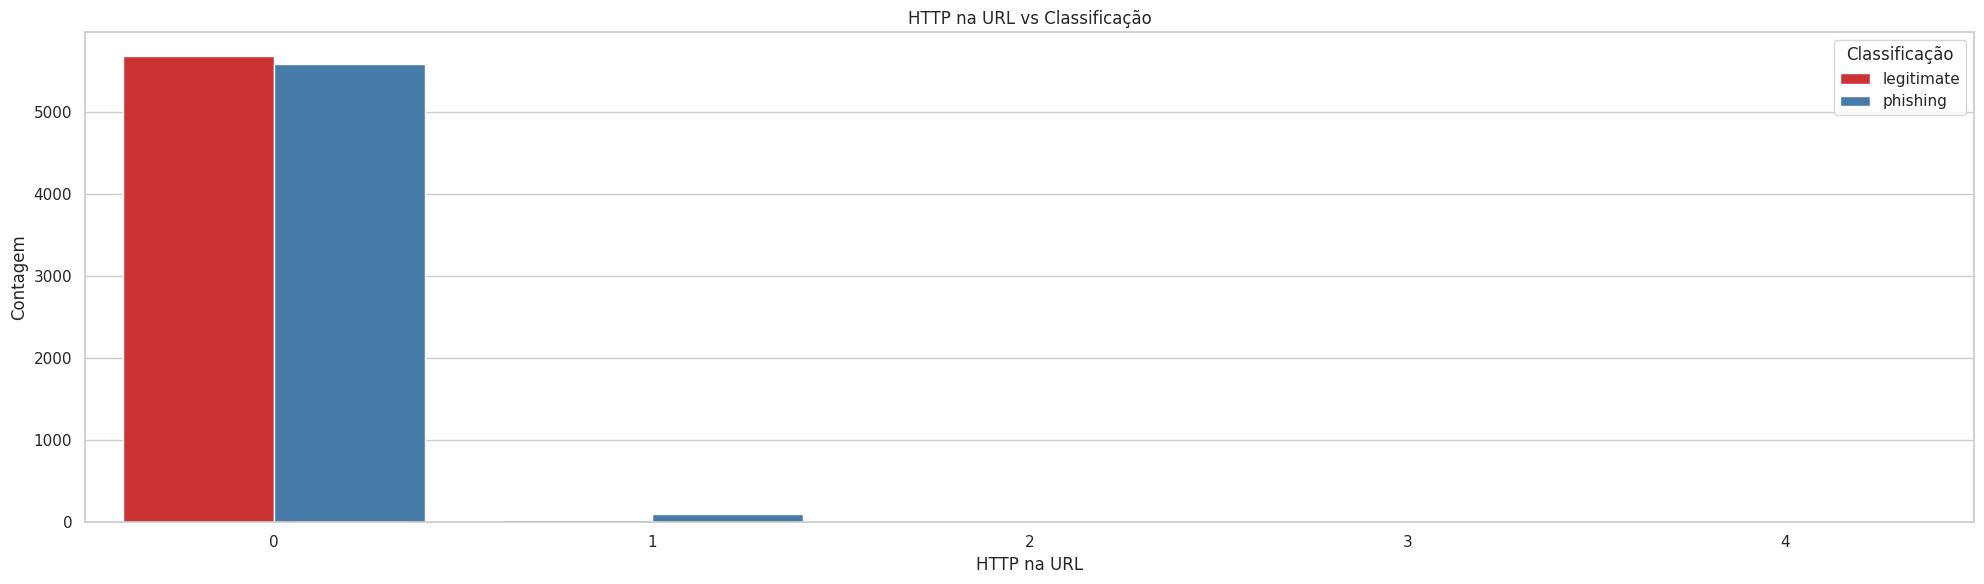

In [42]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='http_no_caminho',
    hue='classificacao',
    palette='Set1'
)

plt.title('HTTP na URL vs Classificação')
plt.xlabel('HTTP na URL')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Analisando as duas features, percebemos que a métrica de 'www'possue uma relevância maior sobre a classificação das urls pois quando temos a expressão a maioria das urls são legítimas e quando falta o 'www' temos a maioria para urls de phishing.

Para a 'http' percebemos que quase 100% do dataset não possui por isso fica irrelevânte para nossa análise.

####Décima pergunta

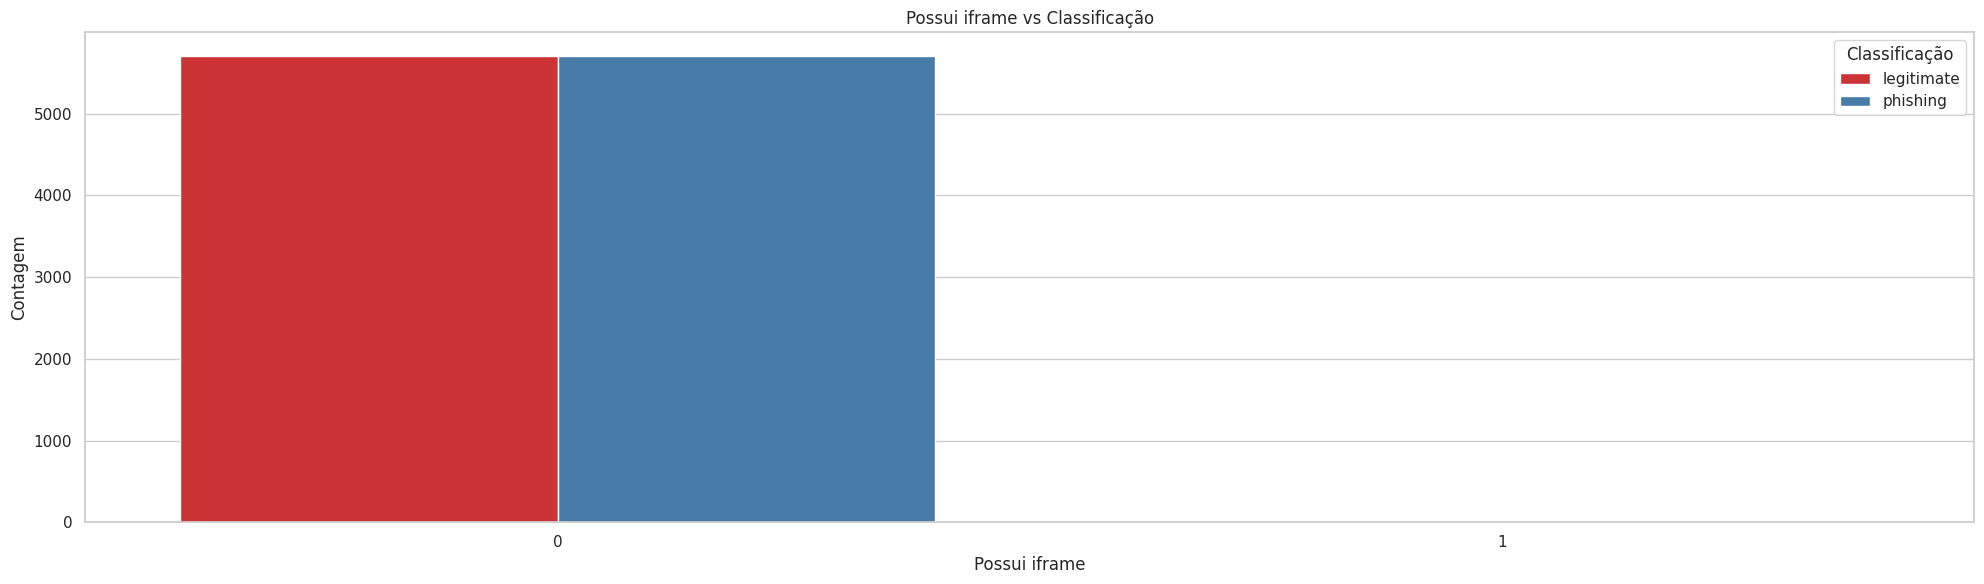

In [43]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='possui_iframe',
    hue='classificacao',
    palette='Set1'
)

plt.title('Possui iframe vs Classificação')
plt.xlabel('Possui iframe')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

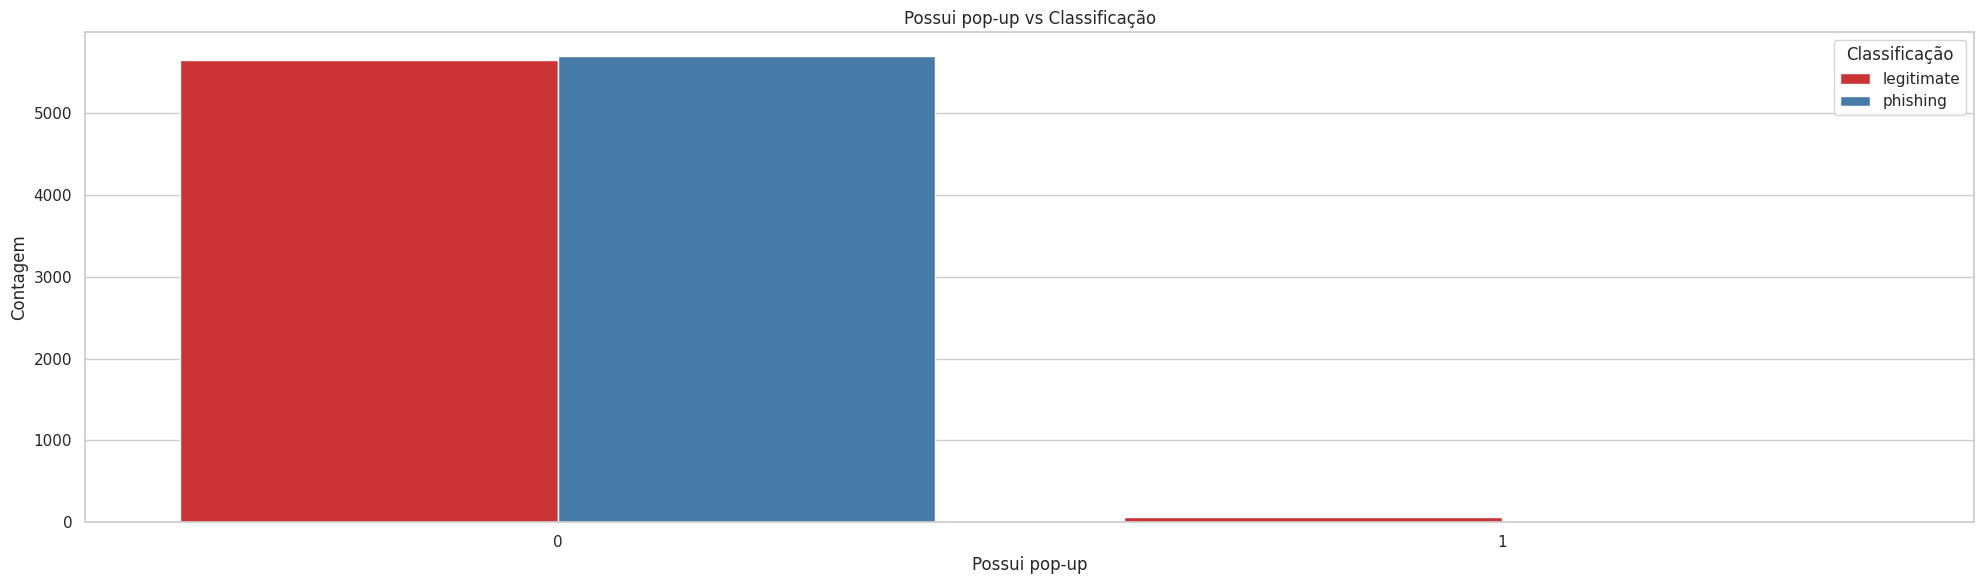

In [44]:
plt.figure(figsize=(20, 6))

sns.countplot(
    data=df,
    x='possui_popup',
    hue='classificacao',
    palette='Set1'
)

plt.title('Possui pop-up vs Classificação')
plt.xlabel('Possui pop-up')
plt.ylabel('Contagem')
plt.legend(title='Classificação')

plt.tight_layout()
plt.show()

**Resposta para a pergunta**: Analisando ambas as features, quase 100% dos casos das urls não possuem nem iframe e popup. Por isso, mesmo achando que seriam métricas relevantes para nosso modelo, mostraram-se ineficazes.

# 2. Pré-processamento (Enconding, tratamento de nulos, balanceamento, etc)

#### 2.1 Remoção de outliers

In [45]:
# Analisando nosso dataset, não identificamos nenhum outlier muito extremo que faça sentido removê-lo.
# Como estamos lidando com métricas bem específicas e não usuais de nosso conhecimento
# Não encontramos uma forma de remover alguns outilers necessários, devido a complexidade das features e a quantidade (quase 90)
# Por isso, optamos por não remover nenhum outlier das colunas

#### 2.2 Tratamento de nulos

In [46]:
#No dataset de phishing não temos nenhum dado nulo, por isso não trataremos nesse código

#### 2.3 Enconding (Target 'status')

In [47]:
#Para transformar a variavel em numerica para a modelagem realizamos um replace
df['classificacao'] = df['classificacao'].replace({'legitimate': 0, 'phishing': 1})

print(df['classificacao'].value_counts())
print(df['classificacao'].dtype)

classificacao
0    5715
1    5715
Name: count, dtype: int64
int64


#### 2.4 Balanceamento do target 'classificacao'

In [48]:
#No nosso dataset a target 'classificacao' está balanceada (50% Phishing e 50% Legitimate)

#### 2.5 Criação de Novas Variáveis (Feature Engineering)

Pensamos em criar uma variável que junta todas as variáveis relacionadas a caracteres especiais para diminuir um pouco o numero de features

In [49]:
# Engloba todos os contadores de caracteres especiais em uma única feature
df['caracteres_especiais'] = (
    df['quantidade_arrobas(@)'] + df['quantidade_interrogacoes(?)'] +
    df['quantidade_e_comercial(&)'] + df['quantidade_igual(=)'] +
    df['quantidade_underscore(_)'] + df['quantidade_percentual(%)'] +
    df['quantidade_til(˜)'] + df['quantidade_asteriscos(*)'] +
    df['quantidade_virgulas(,)'] + df['quantidade_ponto_virgula(;)'] +
    df['quantidade_cifroes($)'] + df['quantidade_espacos( )']
)
df.drop(columns=[
    'quantidade_arrobas(@)', 'quantidade_interrogacoes(?)',
    'quantidade_e_comercial(&)', 'quantidade_igual(=)',
    'quantidade_underscore(_)', 'quantidade_percentual(%)',
    'quantidade_til(˜)', 'quantidade_asteriscos(*)',
    'quantidade_virgulas(,)', 'quantidade_ponto_virgula(;)',
    'quantidade_cifroes($)', 'quantidade_espacos( )'
], inplace=True)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 78 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   url                                    11430 non-null  object 
 1   tamanho_url                            11430 non-null  int64  
 2   tamanho_hostname                       11430 non-null  int64  
 3   endereco_ip                            11430 non-null  int64  
 4   quantidade_pontos(.)                   11430 non-null  int64  
 5   quantidade_hifens(-)                   11430 non-null  int64  
 6   quantidade_ou(\)                       11430 non-null  int64  
 7   quantidade_barras(/)                   11430 non-null  int64  
 8   quantidade_dois_pontos(:)              11430 non-null  int64  
 9   quantidade_palavra_www                 11430 non-null  int64  
 10  quantidade_palavra_com                 11430 non-null  int64  
 11  qu

In [51]:
df

,url,tamanho_url,tamanho_hostname,endereco_ip,quantidade_pontos(.),quantidade_hifens(-),quantidade_ou(\),quantidade_barras(/),quantidade_dois_pontos(:),quantidade_palavra_www,...,dominio_no_copyright,dominio_registrado_whois,tempo_registro_dominio,idade_dominio,trafego_web,possui_registro_dns,indexado_google,rank_da_pagina,classificacao,caracteres_especiais
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,3,1,1,...,1,0,45,-1,0,1,1,4,0,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,5,1,0,...,0,0,77,5767,0,0,1,2,1,0
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,5,1,0,...,0,0,14,4004,5828815,0,1,0,1,8
3,http://rgipt.ac.in,18,11,0,2,0,0,2,1,0,...,0,0,62,-1,107721,0,0,3,0,0
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,5,1,1,...,1,0,224,8175,8725,0,0,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,http://www.fontspace.com/category/blackletter,45,17,0,2,0,0,4,1,1,...,0,0,448,5396,3980,0,0,6,0,0
11426,http://www.budgetbots.com/server.php/Server%20...,84,18,0,5,0,0,5,1,1,...,0,0,211,6728,0,0,1,0,1,5
11427,https://www.facebook.com/Interactive-Televisio...,105,16,1,2,6,0,5,1,1,...,0,0,2809,8515,8,0,1,10,0,3
11428,http://www.mypublicdomainpictures.com/,38,30,0,2,0,0,3,1,1,...,0,0,85,2836,2455493,0,0,4,0,0


#### 2.6 Remoção de features

No nosso dataset, temos 89 features. Após o feature engineering sobramos com 77 features, sendo 2 delas objects (url e classificacao) e 75 métricas numéricas.

Devido a isso, faremos a remoção da feature 'url' pois não será importante para nossos modelos



In [52]:
df.drop(columns=['url'], inplace=True)

# 3. Modelagem supervisionada

Escolhemos os 5 modelos de classificação supervisionados para em sequência realizar uma comparação com métricas apropriadas ao problema (matriz de confusão, acurácia, precisão, recall, F1, AUC dependendo do que faz sentido para o contexto de negócio), e justificar a escolha do "modelo vencedor":

1. Regressão Logística
2. Árvore de Decisão
3. Random Forest
4. XGBoost
5. SVM

Além disso, plotar a feature importance e algum gráfico de SHAP Values para
interpretar o modelo vencedor.


#### 3.1 Divisão das variáveis em X e Y

In [53]:
# Separar X e y

X = df.drop('classificacao', axis=1)
y = df["classificacao"]

In [54]:
#divisão em uma parte para treinamento e o restante para realizar os testes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X:", X.shape, "| Treino:", X_train.shape, "| Teste:", X_test.shape)

X: (11430, 76) | Treino: (9144, 76) | Teste: (2286, 76)


#### 3.2 Tratamento de valores numéricos: Scalers (Padronização)

In [55]:
# Como temos diferênça entre as variáveis numéricas, faremos um tratamento - scalers
# Nessa parte utilizaremos o standardScaler depois do Split

# Instancia o scalerscaler = StandardScaler()
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Padronização concluída (média ~0, desvio ~1).")
X_train_scaled.describe().T[["mean", "std"]].head()

Padronização concluída (média ~0, desvio ~1).


,mean,std
tamanho_url,2.855692e-17,1.000055
tamanho_hostname,-1.425903e-16,1.000055
endereco_ip,-4.390383e-17,1.000055
quantidade_pontos(.),1.524978e-16,1.000055
quantidade_hifens(-),-2.039780e-18,1.000055


#### 3.3 Treinando todos os modelo:

1. Regressão Logística
2. Árvore de Decisão
3. Random Forest
4. XGBoost
5. KNN




In [56]:
# Definindo o modelo de Regressão Logística

model_log = LogisticRegression()

In [57]:
# Treinar o modelo LogisticRegression
model_log.fit(X_train_scaled, y_train)

LogisticRegression()

In [58]:
# Definindo o modelo de Árvore de Decisão

model_tree = DecisionTreeClassifier(
    criterion='gini',
    class_weight='balanced',
    max_depth=10,
    random_state=42
)

In [59]:
# Treinar o modelo DecisionTreeClassifier

model_tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [60]:
# Definindo o modelo de Random Forest

model_forest = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    class_weight = "balanced"
)

In [61]:
# Treinando o modelo RandomForestClassifier
model_forest.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [62]:
#Definindo o modelo XGBoost
model_xgb = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state = 42
)


In [63]:
# Treinando o modelo XGBClassifier
model_xgb.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [64]:
# Definindo o modelo KNN
model_knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='minkowski',
    p=2,
    weights='uniform',
    n_jobs=-1
)

In [65]:
# Treinando o modelo KNeighborsClassifier
model_knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_jobs=-1)

#### 3.3 Previsões, probabilidades de todos os modelo:

In [66]:
# Fazer previsões do modelo de Regressão logística
y_pred_log = model_log.predict(X_test_scaled)

y_pred_log

array([0, 0, 0, ..., 1, 0, 1])

In [67]:
# Fazer previsões do modelo de Árvore de Decisão
y_pred_tree = model_tree.predict(X_test_scaled)

y_pred_tree

array([0, 0, 0, ..., 0, 0, 1])

In [68]:
# Fazer previsões do modelo de Random Forest
y_pred_forest = model_forest.predict(X_test_scaled)

y_pred_forest

array([0, 0, 0, ..., 1, 0, 1])

In [69]:
# Fazer previsões do modelo de XGBoost
y_pred_xgb = model_xgb.predict(X_test_scaled)

y_pred_xgb

array([0, 0, 0, ..., 1, 0, 1])

In [70]:
# Fazer previsões do modelo de KNN
y_pred_knn = model_knn.predict(X_test_scaled)

y_pred_knn

array([0, 0, 0, ..., 1, 0, 1])

In [71]:
# Analisando as probabilidades do modelo de Regressão logística

np.set_printoptions(suppress=True, precision=8)
y_probs_log = model_log.predict_proba(X_test_scaled)[:, 1]

y_probs_log

array([0.01780944, 0.09217943, 0.00022692, ..., 0.99919124, 0.00023875,
       0.94874659])

In [72]:
# Analisando as probabilidades do modelo de Árvore de Decisão

np.set_printoptions(suppress=True, precision=8)
y_probs_tree = model_tree.predict_proba(X_test_scaled)[:, 1]

y_probs_tree

array([0.00537258, 0.07457623, 0.00537258, ..., 0.13262723, 0.00537258,
       0.99803362])

In [73]:
# Analisando as probabilidades do modelo de Random Forest

np.set_printoptions(suppress=True, precision=8)
y_probs_forest = model_forest.predict_proba(X_test_scaled)[:, 1]

y_probs_forest

array([0.02, 0.11, 0.  , ..., 0.81, 0.  , 1.  ])

In [74]:
# Analisando as probabilidades do modelo de XGBoost

np.set_printoptions(suppress=True, precision=8)
y_probs_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

y_probs_xgb

array([0.00001332, 0.00536632, 0.00011922, ..., 0.99497885, 0.00069671,
       0.9991503 ], dtype=float32)

In [75]:
# Analisando as probabilidades do modelo de KNN

np.set_printoptions(suppress=True, precision=8)
y_probs_knn = model_knn.predict_proba(X_test_scaled)[:, 1]

y_probs_knn

array([0. , 0.4, 0. , ..., 1. , 0. , 0.8])

#### 3.4 Classification Report, Matriz de Confusão e Curvas para todos os modelos (ROC AUC e AUC PR)

In [76]:
# Classification report da Regressão Logística

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1157
           1       0.95      0.95      0.95      1129

    accuracy                           0.95      2286
   macro avg       0.95      0.95      0.95      2286
weighted avg       0.95      0.95      0.95      2286



In [77]:
# Classification report da Árvore de Decisão

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1157
           1       0.94      0.92      0.93      1129

    accuracy                           0.93      2286
   macro avg       0.93      0.93      0.93      2286
weighted avg       0.93      0.93      0.93      2286



In [78]:
# Classification report da Random Forest

print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1157
           1       0.97      0.96      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



In [79]:
# Classification report da XGBoost

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1157
           1       0.97      0.97      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



In [80]:
# Classification report da KNN

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1157
           1       0.96      0.92      0.94      1129

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



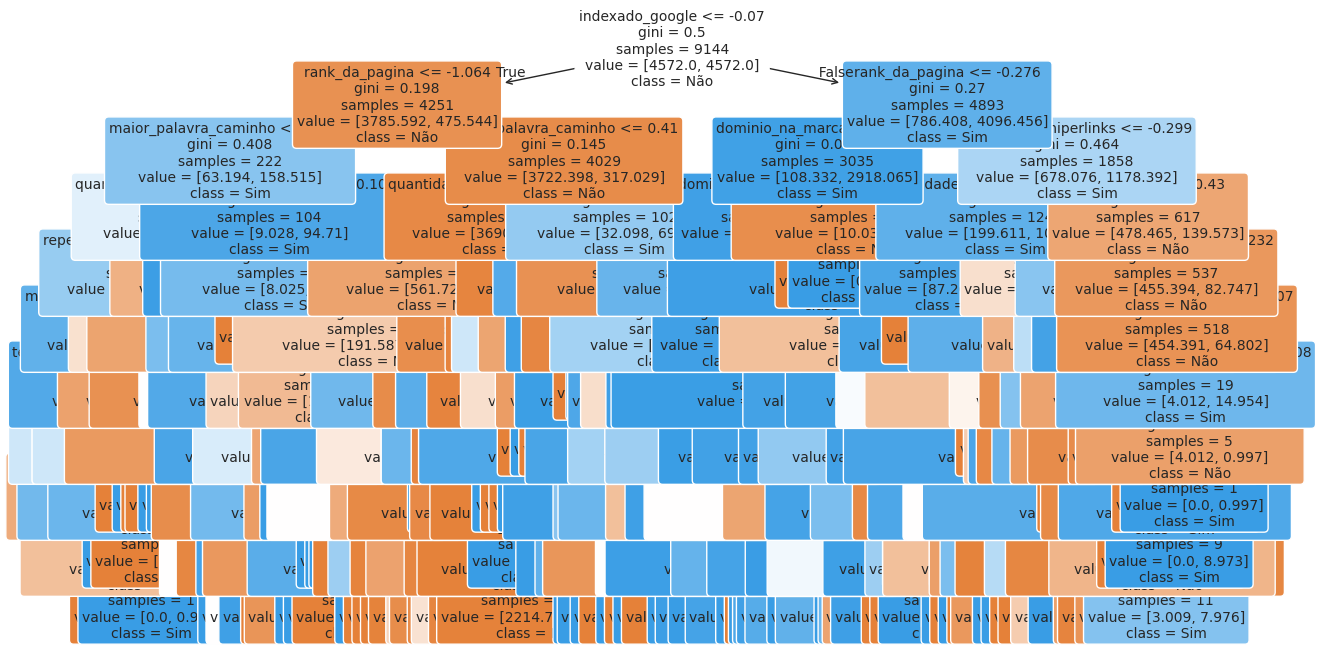

In [81]:
#Plotando a Árvore de decisão

plt.figure(figsize=(14,8))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=['Não', 'Sim'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

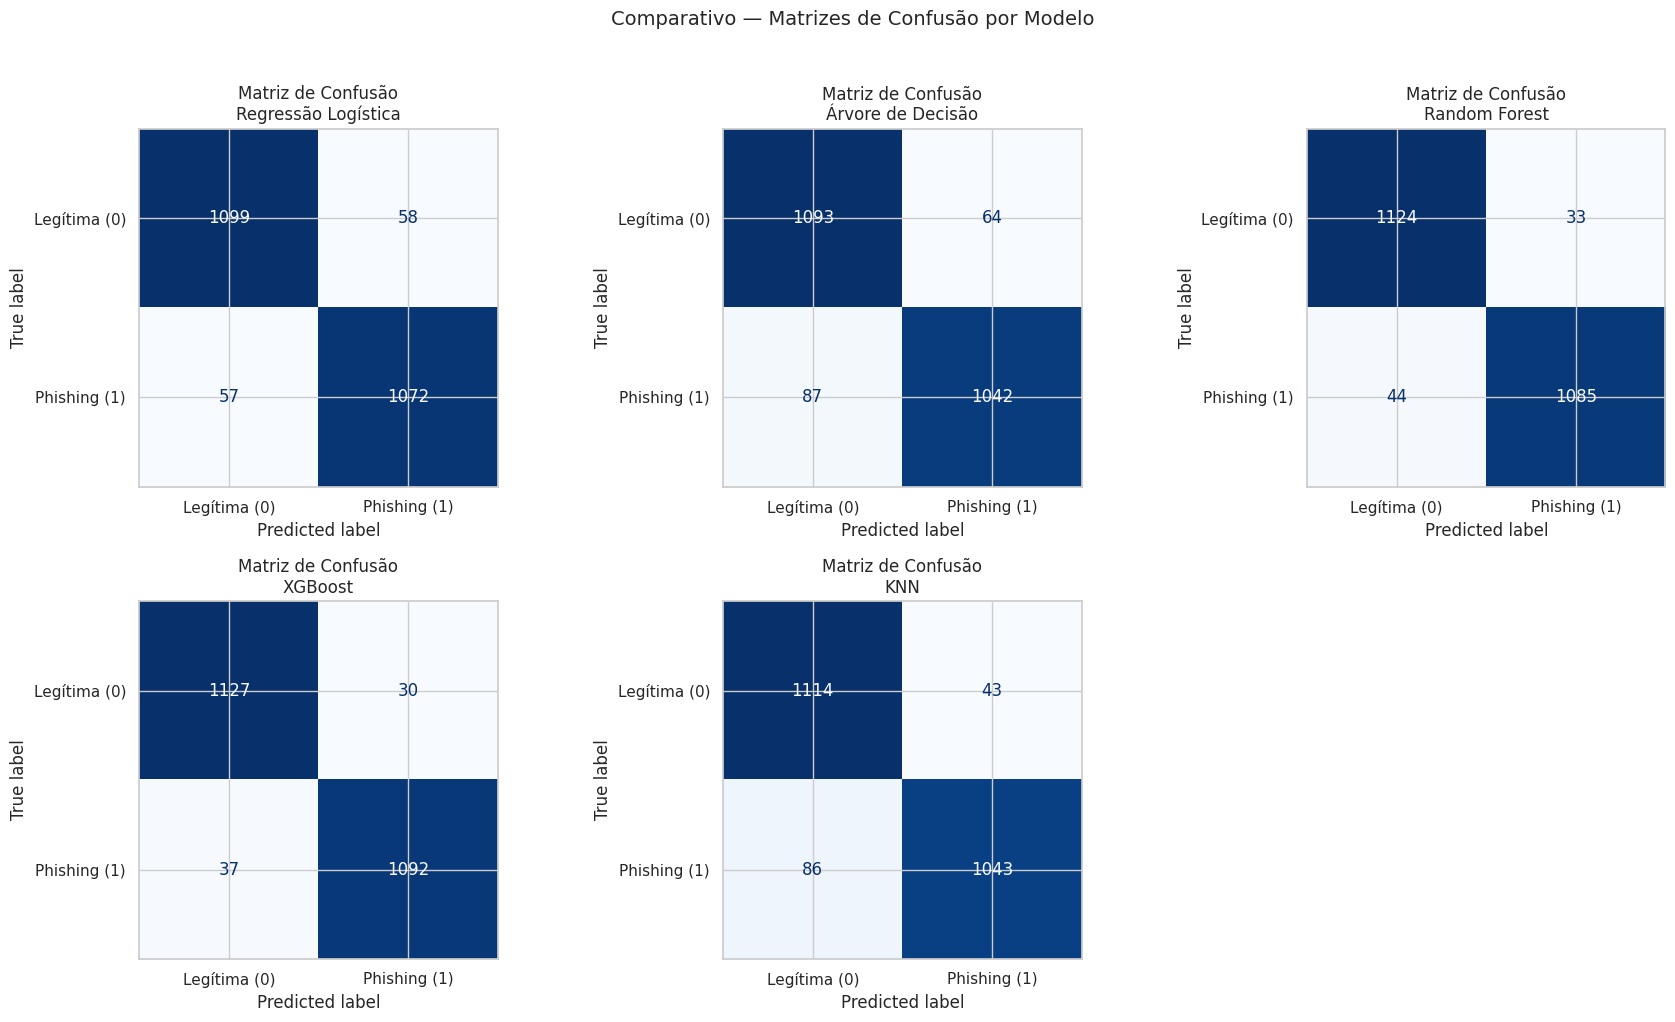

In [82]:
# Plotando as matrizes de confusão de todos os modelos

modelos = [
    (model_log, 'Regressão Logística'),
    (model_tree, 'Árvore de Decisão'),
    (model_forest, 'Random Forest'),
    (model_xgb, 'XGBoost'),
    (model_knn, 'KNN'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (modelo, titulo) in enumerate(modelos):
    y_pred = modelo.predict(X_test_scaled)

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Legítima (0)', 'Phishing (1)'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'Matriz de Confusão\n{titulo}', fontsize=12)

fig.delaxes(axes[5])

plt.suptitle('Comparativo — Matrizes de Confusão por Modelo',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

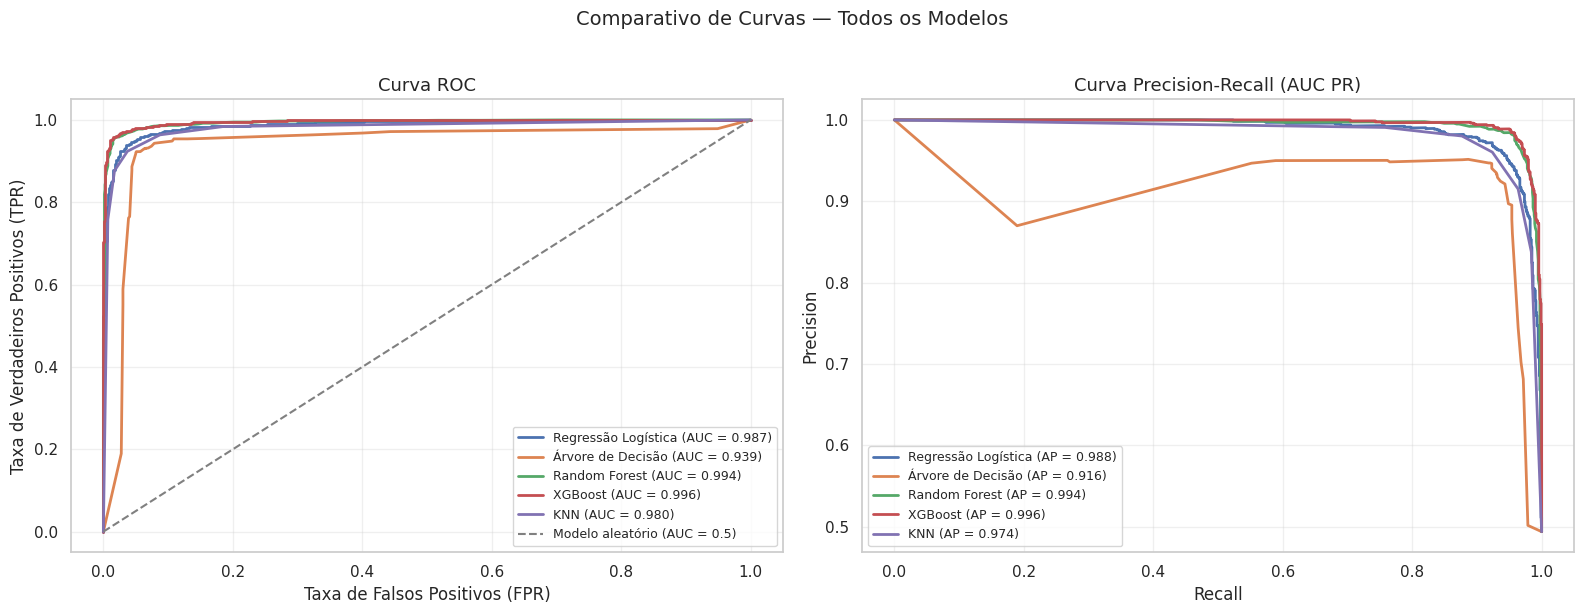

Modelo                       ROC AUC  AUC PR (AP)
------------------------------------------------
Regressão Logística           0.9874       0.9884
Árvore de Decisão             0.9393       0.9159
Random Forest                 0.9939       0.9940
XGBoost                       0.9956       0.9958
KNN                           0.9799       0.9740


In [83]:
# Nessa parte, utilizando o claude.ai como suporte de pesquisa para o código.
# Coloquei o código sugerido e revisado com as variáveis e nomemclaturas corretas para plotar as curvas ROC-AUC e AUC-PR

# Probabilidades de cada modelo (coluna 1 = classe positiva)
y_probs_log = model_log.predict_proba(X_test_scaled)[:, 1]
y_probs_tree = model_tree.predict_proba(X_test_scaled)[:, 1]
y_probs_forest = model_forest.predict_proba(X_test_scaled)[:, 1]
y_probs_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]
y_probs_knn = model_knn.predict_proba(X_test_scaled)[:, 1]

# Configuração dos modelos: nome, probabilidades e cor
modelos = [
    ('Regressão Logística', y_probs_log, '#4C72B0'),
    ('Árvore de Decisão', y_probs_tree, '#DD8452'),
    ('Random Forest', y_probs_forest, '#55A868'),
    ('XGBoost', y_probs_xgb, '#C44E52'),
    ('KNN', y_probs_knn, '#8172B2'),
]

# Calculando curvas e métricas para cada modelo
resultados = []
for nome, y_prob, cor in modelos:
    fpr,  tpr,  _ = roc_curve(y_test, y_prob)
    prec, rec,  _ = precision_recall_curve(y_test, y_prob)
    auc_roc = roc_auc_score(y_test, y_prob)
    auc_pr = average_precision_score(y_test, y_prob)
    resultados.append((nome, fpr, tpr, prec, rec, auc_roc, auc_pr, cor))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for nome, fpr, tpr, prec, rec, auc_roc, auc_pr, cor in resultados:
    axes[0].plot(fpr, tpr, label=f'{nome} (AUC = {auc_roc:.3f})', color=cor, lw=2)
    axes[1].plot(rec, prec, label=f'{nome} (AP = {auc_pr:.3f})',  color=cor, lw=2)

# Gráfico 1: ROC AUC
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray',
             label='Modelo aleatório (AUC = 0.5)')
axes[0].set_title('Curva ROC', fontsize=13)
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Gráfico 2: AUC PR
axes[1].set_title('Curva Precision-Recall (AUC PR)', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('Comparativo de Curvas — Todos os Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Resumo numérico
print(f"{'Modelo':<25} {'ROC AUC':>10} {'AUC PR (AP)':>12}")
print("-" * 48)
for nome, _, _, _, _, auc_roc, auc_pr, _ in resultados:
    print(f"{nome:<25} {auc_roc:>10.4f} {auc_pr:>12.4f}")

#### 3.5 Comparação dos modelos estudados

COMPARAÇÃO DE MÉTRICAS — TODOS OS MODELOS
                     Acurácia  Precisão  Recall  F1-Score
Modelo                                                   
XGBoost                0.9707    0.9707  0.9706    0.9707
Random Forest          0.9663    0.9664  0.9663    0.9663
Regressão Logística    0.9497    0.9497  0.9497    0.9497
KNN                    0.9436    0.9444  0.9433    0.9435
Árvore de Decisão      0.9339    0.9342  0.9338    0.9339


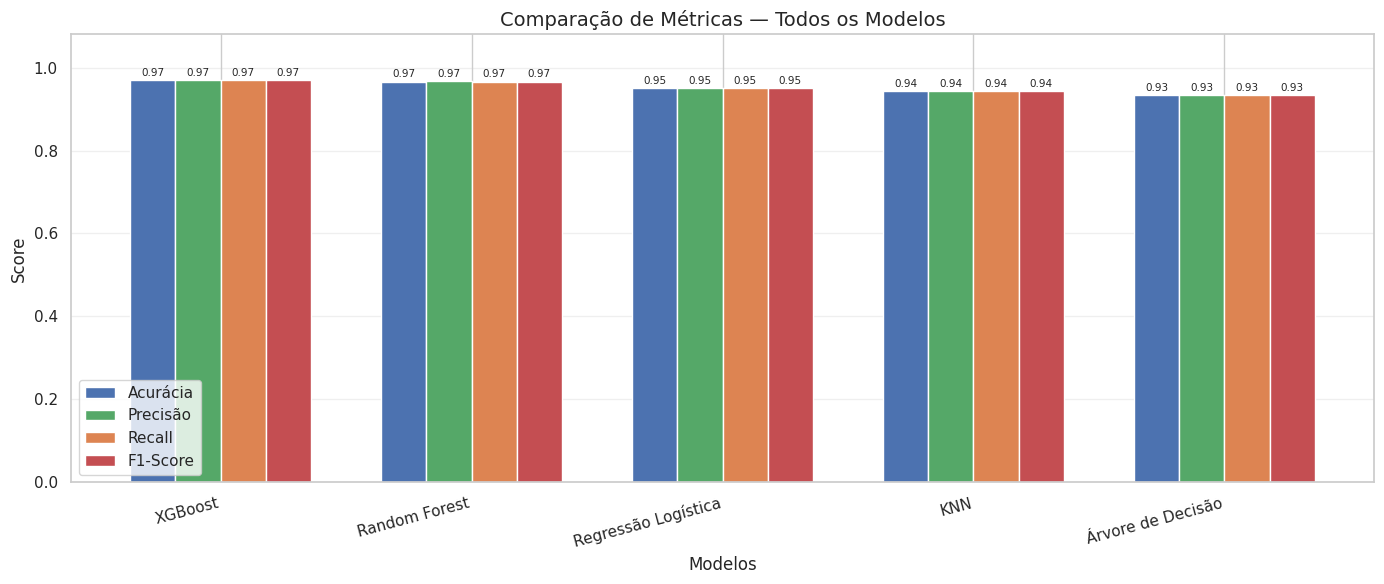

In [84]:
# Dicionário com nome do modelo → (modelo, X_test a usar)
# Todos os modelos foram treinados com X_train_scaled
modelos = {
    'Regressão Logística': (model_log,    X_test_scaled),
    'Árvore de Decisão':   (model_tree,   X_test_scaled),
    'Random Forest':       (model_forest, X_test_scaled),
    'XGBoost':             (model_xgb,    X_test_scaled),
    'KNN':                 (model_knn,    X_test_scaled),
}

# Coleta as métricas de cada modelo
resultados = []
for nome, (modelo, X) in modelos.items():
    y_pred = modelo.predict(X)
    resultados.append({
        'Modelo':   nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall':   recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='macro', zero_division=0),
    })

df_resultados = (pd.DataFrame(resultados)
                   .set_index('Modelo')
                   .sort_values('F1-Score', ascending=False))

# ── Tabela resumo ─────────────────────────────────────────────
print("COMPARAÇÃO DE MÉTRICAS — TODOS OS MODELOS")
print(df_resultados.round(4).to_string())

# ── Gráfico de barras agrupadas ───────────────────────────────
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
cores    = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

x     = np.arange(len(df_resultados))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metrica, cor) in enumerate(zip(metricas, cores)):
    offset = (i - len(metricas) / 2) * width + width / 2
    bars = ax.bar(x + offset, df_resultados[metrica], width,
                  label=metrica, color=cor, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Modelos', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparação de Métricas — Todos os Modelos', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados.index, rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.6 — Identificando o Modelo vencedor e justificando a escolha

In [85]:
# Identifica o melhor modelo com base no F1-Score
# df_resultados já está ordenado por F1-Score decrescente
melhor_modelo_nome = df_resultados.index[0]

# Recupera o objeto do modelo pelo nome
melhor_modelo = {
    'Regressão Logística': model_log,
    'Árvore de Decisão':   model_tree,
    'Random Forest':       model_forest,
    'XGBoost':             model_xgb,
    'KNN':                 model_knn,
}[melhor_modelo_nome]

print("Modelo vencedor (maior F1):", melhor_modelo_nome)
display(df_resultados.iloc[[0]].round(4))

Modelo vencedor (maior F1): XGBoost


,Acurácia,Precisão,Recall,F1-Score
Modelo,,,,
XGBoost,0.9707,0.9707,0.9706,0.9707


Justificativa: escolhemos o vencedor pelo F1-Score porque, no combate ao phishing, deixar um golpe passar (falso negativo) é mais custoso do que revisar um site legítimo à toa (falso positivo). O F1 equilibra recall e precisão, e o AUC confirma a capacidade de separação das classes.

#### 3.7 — Feature Importance do modelo vencedor (XGBoost)

In [86]:
imp = permutation_importance(
    melhor_modelo, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1',
    n_jobs=-1
)

imp_df = (pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Importância': imp.importances_mean
})
.sort_values('Importância', ascending=False)
.reset_index(drop=True))

display(imp_df.head(25))

,Feature,Importância
0,rank_da_pagina,0.066895
1,indexado_google,0.032461
2,quantidade_palavra_www,0.020629
3,quantidade_barras(/),0.007250
4,indicadores_phishing,0.007183
5,tamanho_palavras_brutas,0.005913
6,idade_dominio,0.005326
7,quantidade_pontos(.),0.004892
8,quantidade_hiperlinks,0.004673
9,token_https,0.003321


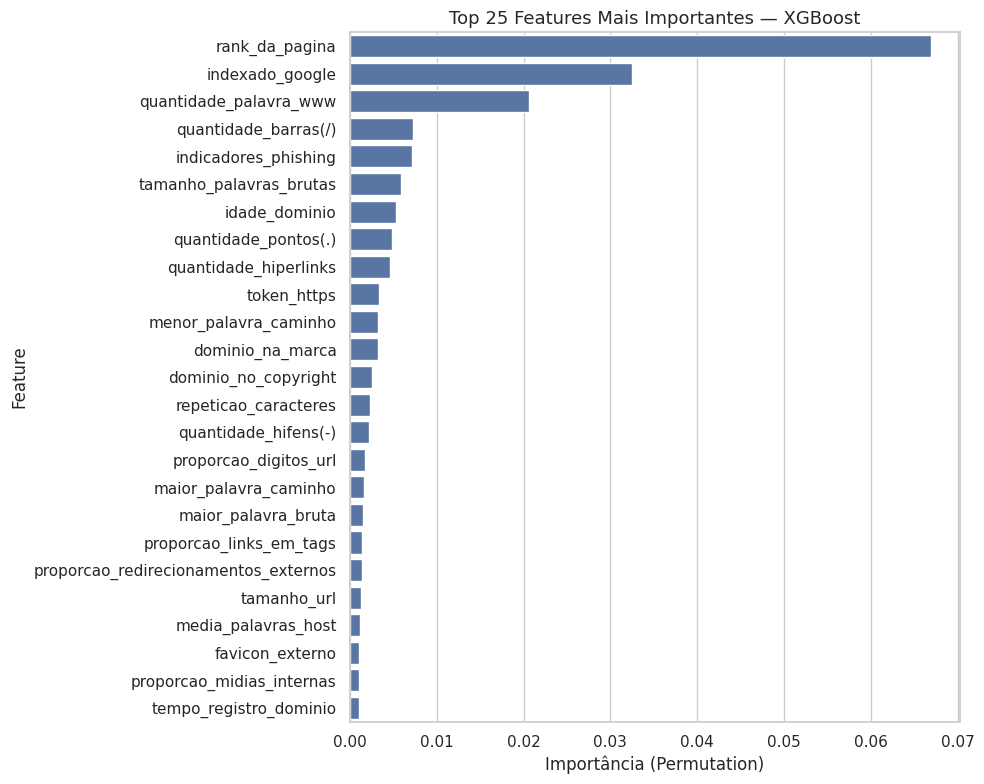

In [87]:
plt.figure(figsize=(10, 8))
sns.barplot(data=imp_df.head(25), x='Importância', y='Feature', color='#4C72B0')
plt.title(f'Top 25 Features Mais Importantes — {melhor_modelo_nome}', fontsize=13)
plt.xlabel('Importância (Permutation)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### 3.8 — SHAP Values do modelo vencedor (XGBoost)

Valores SHAP calculados para: XGBoost
Shape dos valores SHAP: (200, 76)


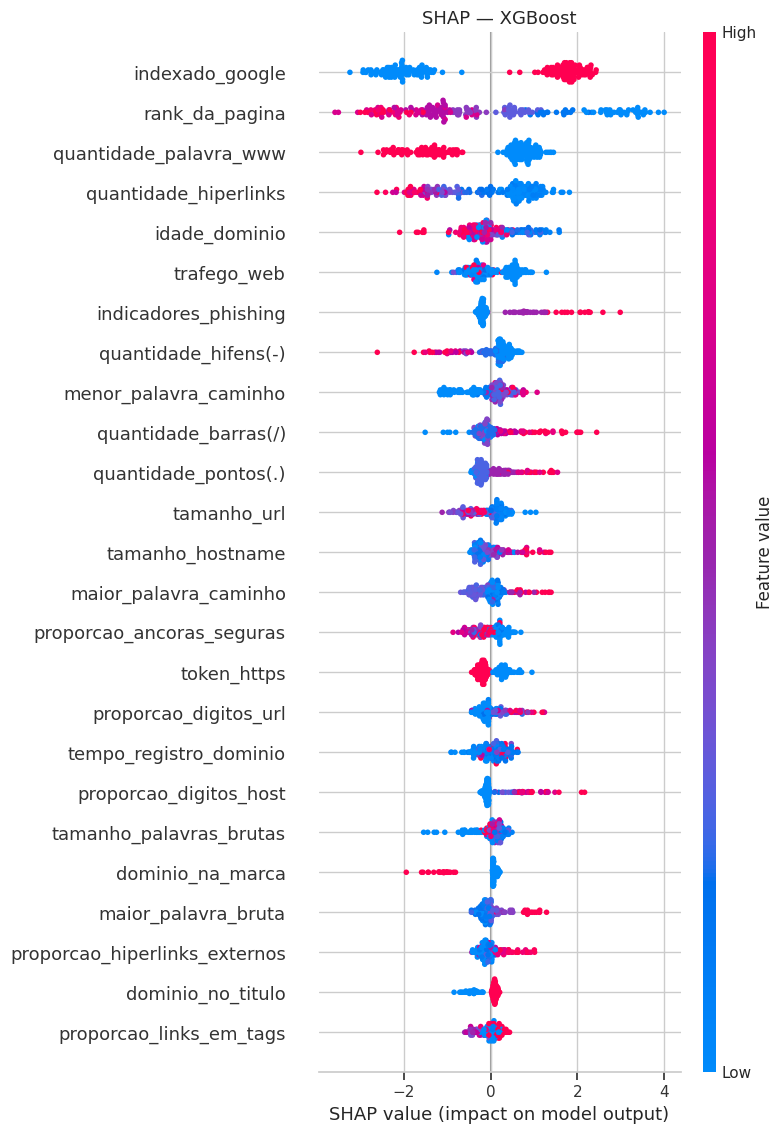

In [89]:
warnings.filterwarnings('ignore')

# Amostragem dos dados
X_shap = X_test_scaled.sample(min(200, len(X_test_scaled)), random_state=42)

# CORREÇÃO: Definir X_shap_np no escopo global antes do if/else
X_shap_np = X_shap.to_numpy()

def shap_classe_phishing(sv):
    if isinstance(sv, list):
        return sv[1]
    sv = np.asarray(sv)
    return sv[:, :, 1] if sv.ndim == 3 else sv

# Escolha do Explainer
if melhor_modelo_nome in ['Random Forest', 'Árvore de Decisão', 'XGBoost']:
    explainer = shap.TreeExplainer(melhor_modelo)
    valores = shap_classe_phishing(explainer.shap_values(X_shap))
else:
    fundo_np = shap.sample(X_train_scaled, min(50, len(X_train_scaled))).to_numpy()

    def predict_proba_fn(X):
        return melhor_modelo.predict_proba(X)

    explainer = shap.KernelExplainer(predict_proba_fn, fundo_np)
    valores = shap_classe_phishing(explainer.shap_values(X_shap_np, nsamples=100))

print(f"Valores SHAP calculados para: {melhor_modelo_nome}")
print(f"Shape dos valores SHAP: {np.array(valores).shape}")

# Gerando o gráfico
shap.summary_plot(
    valores,
    X_shap_np, # Agora essa variável existe para qualquer modelo!
    feature_names=X_test_scaled.columns.tolist(),
    max_display=25,
    show=False   # Impede o SHAP de exibir o gráfico automaticamente e duplicá-lo
)

plt.title(f'SHAP — {melhor_modelo_nome}', fontsize=13)
plt.tight_layout()
plt.show()

# 4. Otimização de hiperparâmetros

O modelo vencedor é o **XGBoost**, usando a metrica maior F1-Score na comparação decidimos que esse foi o modelo campeão entre todos os estudados.

Como o XGBoost tem um espaço de hiperparâmetros grande e contínuo (learning_rate, profundidade, regularização, subamostragem, etc.), a técnica mais adequada aqui é o **Optuna**.

Pesquisando sobre o XGBoost, o conselho foi utilizar o optuna para otimizar hiperparâmetros, buscando uma melhora nos resultados do modelo. Ainda assim, utilizaremos uma outra técnica de busca e aprimoramento chamada `'RandomizedSearchCV'`

#### 4.1 Usando o modelo treinado do XGBoost com hiperparâmetros padrão

In [90]:
# Reaproveita o modelo já treinado na Seção 3 (model_xgb == melhor_modelo)
y_pred_base = melhor_modelo.predict(X_test_scaled)
y_prob_base = melhor_modelo.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'Acurácia': accuracy_score(y_test, y_pred_base),
    'Precisão': precision_score(y_test, y_pred_base, average='macro', zero_division=0),
    'Recall':   recall_score(y_test, y_pred_base, average='macro', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_base, average='macro', zero_division=0),
    'ROC AUC':  roc_auc_score(y_test, y_prob_base),
}

print(f"Baseline — {melhor_modelo_nome} (parâmetros padrão):")
for k, v in baseline_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

Baseline — XGBoost (parâmetros padrão):
  Acurácia  : 0.9707
  Precisão  : 0.9707
  Recall    : 0.9706
  F1-Score  : 0.9707
  ROC AUC   : 0.9956


#### 4.2 Realizando uma busca bayesiana de hiperparâmetros com Optuna

A otimização usa **validação cruzada (cv=5) apenas no conjunto de treino** — o conjunto de teste não é olhado nessa etapa, evitando vazamento de dados. A métrica otimizada é o **F1-Score**.

In [93]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':     42,
        'eval_metric':      'logloss',
        'n_jobs':           -1,
    }
    modelo = xgb.XGBClassifier(**params)
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("\nMelhores hiperparâmetros encontrados pelo Optuna:")
print(study.best_params)
print(f"Melhor F1-Score (macro) médio em validação cruzada: {study.best_value:.4f}")


  0%|          | 0/40 [00:00<?, ?it/s]


Melhores hiperparâmetros encontrados pelo Optuna:
{'n_estimators': 336, 'max_depth': 8, 'learning_rate': 0.09618941782740617, 'subsample': 0.6026168324121943, 'colsample_bytree': 0.9496616579856164, 'min_child_weight': 4, 'gamma': 0.553617064887679, 'reg_alpha': 9.578146743387918e-05, 'reg_lambda': 4.2507177342658914e-05}
Melhor F1-Score (macro) médio em validação cruzada: 0.9656


**Observações dos melhores hiperparâmetros:** Como a análise nos mostrou podemos categorizar os melhores hiperparâmetros para o Optuna buscando assim uma melhor otimização do modelo XGBoost:

- n_estimators;
- max_depth;
- learning_rate;
- subsample;
- colsample_bytree;
- min_child_weight;
- gamma;
- reg_alpha;
- reg_lambda.

#### 4.3 — Re-treina o modelo vencedor (XGBoost) com os melhores hiperparâmetros e avalia no conjunto de teste

In [95]:
melhor_modelo_otimizado = xgb.XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric='logloss'
)
melhor_modelo_otimizado.fit(X_train_scaled, y_train)

y_pred_opt = melhor_modelo_otimizado.predict(X_test_scaled)
y_prob_opt = melhor_modelo_otimizado.predict_proba(X_test_scaled)[:, 1]

opt_metrics = {
    'Acurácia': accuracy_score(y_test, y_pred_opt),
    'Precisão': precision_score(y_test, y_pred_opt, average='macro', zero_division=0),
    'Recall':   recall_score(y_test, y_pred_opt, average='macro', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_opt, average='macro', zero_division=0),
    'ROC AUC':  roc_auc_score(y_test, y_prob_opt),
}

print(f"Modelo otimizado — {melhor_modelo_nome} (Optuna):")
for k, v in opt_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

Modelo otimizado — XGBoost (Optuna):
  Acurácia  : 0.9707
  Precisão  : 0.9707
  Recall    : 0.9707
  F1-Score  : 0.9707
  ROC AUC   : 0.9953


#### 4.4 Tabela e gráfico do ganho de performance. Resultado do antes e depois da otimização de hiperparâmetros (padrão x otimizado)

COMPARAÇÃO — MODELO PADRÃO x MODELO OTIMIZADO (Optuna)
          Padrão  Otimizado   Ganho  Ganho (%)
Acurácia  0.9707     0.9707  0.0000     0.0000
Precisão  0.9707     0.9707 -0.0000    -0.0034
Recall    0.9706     0.9707  0.0000     0.0022
F1-Score  0.9707     0.9707  0.0000     0.0002
ROC AUC   0.9956     0.9953 -0.0003    -0.0251


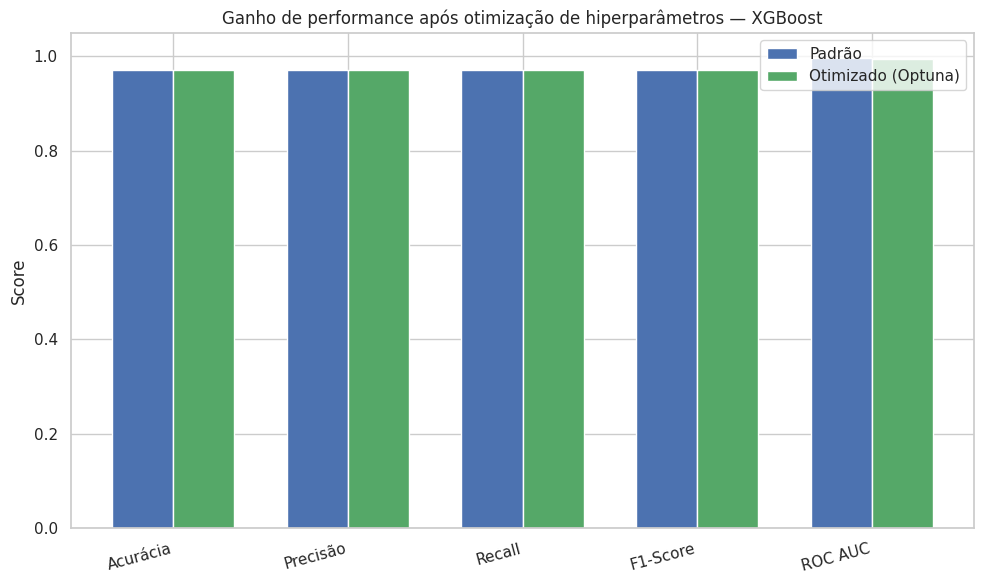

In [96]:
df_comparacao_hp = pd.DataFrame({'Padrão': baseline_metrics, 'Otimizado': opt_metrics})
df_comparacao_hp['Ganho']    = df_comparacao_hp['Otimizado'] - df_comparacao_hp['Padrão']
df_comparacao_hp['Ganho (%)'] = (df_comparacao_hp['Ganho'] / df_comparacao_hp['Padrão']) * 100

print("COMPARAÇÃO — MODELO PADRÃO x MODELO OTIMIZADO (Optuna)")
print(df_comparacao_hp.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_comparacao_hp))
width = 0.35

ax.bar(x - width/2, df_comparacao_hp['Padrão'],    width, label='Padrão',              color='#4C72B0')
ax.bar(x + width/2, df_comparacao_hp['Otimizado'], width, label='Otimizado (Optuna)',  color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(df_comparacao_hp.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title(f'Ganho de performance após otimização de hiperparâmetros — {melhor_modelo_nome}')
ax.legend()
plt.tight_layout()
plt.show()

#### Comentários do ganho com a otimização de hiperparâmetros utilizando o Optuna

- **Ganho positivo no F1-Score** → o Optuna encontrou uma configuração melhor que a padrão: vale adotar `melhor_modelo_otimizado` como modelo final.
- **Ganho próximo de zero ou negativo** → os parâmetros padrão do XGBoost já eram muito bons para este dataset (comum quando o modelo já tem F1 acima de 0.97, como é o caso aqui — sobra pouca margem para melhorar). Isso também é um resultado válido: mostra que a busca não deixou "dinheiro na mesa".

> Observação metodológica: os hiperparâmetros foram escolhidos por validação cruzada apenas no treino; o conjunto de teste só foi usado na comparação final, evitando *data leakage* e tornando o ganho reportado uma estimativa honesta do benefício real.

#### 4.5 Otimizando o XGBoost com outra técnica - `RandomizedSearchCV` para comparação de ganhos

Agora utilizaremos outra técnica de otimização de hiperparâmetros para entender como cada técnica performa no modelo vencedor. Isso é muito importante para comparação de ganhos para cada tipo de otimização.

In [98]:
param_dist = {
    'n_estimators':     [100, 200, 300, 400, 500, 600],
    'max_depth':        [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate':    np.linspace(0.01, 0.3, 20),
    'subsample':        np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'min_child_weight': [1, 2, 3, 4, 5, 6, 8, 10],
}

random_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=40,
    scoring='f1_macro',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
random_search.fit(X_train_scaled, y_train)

y_pred_rs = random_search.best_estimator_.predict(X_test_scaled)

print("RandomizedSearchCV — melhores parâmetros encontrados:")
print(random_search.best_params_)
print(f"F1-Score (macro) no teste: {f1_score(y_test, y_pred_rs, average='macro'):.4f}")
print(f"(Para comparação: Optuna obteve {opt_metrics['F1-Score']:.4f} e o baseline {baseline_metrics['F1-Score']:.4f})")


RandomizedSearchCV — melhores parâmetros encontrados:
{'subsample': np.float64(0.7), 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': np.float64(0.11684210526315789), 'colsample_bytree': np.float64(1.0)}
F1-Score (macro) no teste: 0.9720
(Para comparação: Optuna obteve 0.9707 e o baseline 0.9707)


**Observações do RandomizedSearchCV** Ao contrario do que pesquisamos, essa técnica foi mais efetiva no otimização do XGBoost do que o próprio Optuna. Olhando o F1-Score o valor foi para 0.9720 enquanto no optuna não mudou da baseline 0.9707.

Pensando no valor em si é algo bem baixo, mas quando entendemos que 0.9707 já é muito alto para um modelo. Dificilmente teremos ganhos expressivos utilizando técnicas de hiperparâmetros.

# 5. E se fosse não supervisionado?

Essa é a etapa onde removemos o rótulo do dataset para tentar verificar
como utilizar como um modelo não supervisionado. Aqui adaptamos ponto a ponto para o nosso problema: **phishing (1) vs legítima (0)**.

#### 5.1 Proporção real das classes (antes de rodar qualquer clustering)

Proporção real das classes no dataset:
Legítima (0)    0.5
Phishing (1)    0.5
Name: proportion, dtype: float64


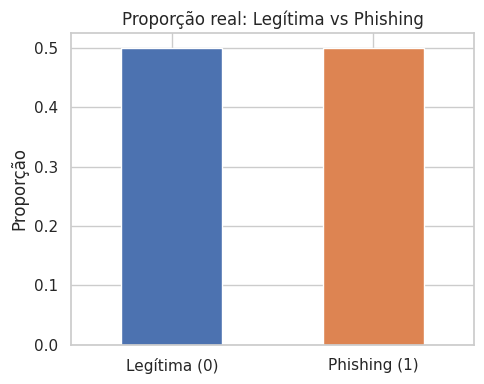

In [99]:
prop_real = y.value_counts(normalize=True).sort_index()
prop_real.index = ['Legítima (0)', 'Phishing (1)']

print("Proporção real das classes no dataset:")
print(prop_real)

plt.figure(figsize=(5, 4))
prop_real.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Proporção real: Legítima vs Phishing')
plt.ylabel('Proporção')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Pergunta 1 (resposta escrita):** *"Vocês esperam que um clustering encontre grupos do mesmo tamanho dessa proporção? Por que sim ou por que não?"*

O dataset está perfeitamente balanceado (50% legítimas, 50% phishing). **Isso não garante, por si só, que o K-Means vá encontrar dois clusters do mesmo tamanho.** O K-Means agrupa por proximidade geométrica nas features padronizadas, sem nenhum conhecimento do rótulo `classificacao`. Dois cenários são possíveis:

- **Se a estrutura de distância nas features já refletir bem a diferença phishing/legítima** (ou seja, se as duas classes formarem "nuvens" bem separadas no espaço das features), é razoável esperar clusters de tamanho parecido com a proporção real.
- **Se existirem subgrupos naturais mais fortes que a divisão phishing/legítima** — por exemplo, sites com URLs muito longas vs muito curtas, independentemente da classe — o K-Means pode formar clusters bem desbalanceados (ex.: 80%/20%) mesmo com o rótulo original balanceado 50/50. Balanceamento de classe **não implica** balanceamento de cluster.

Por isso, o resultado do item 5.3 abaixo é o que realmente responde essa pergunta — a expectativa teórica não substitui a checagem empírica.

#### 5.2 Remover o rótulo e rodar K-Means (k=2) nas mesmas features do modelo supervisionado

Lembrando que utilizamos o K=2 pois sabemos que nossa target possui duas classes. Ou seja, a classificação do dataset é **phishing (1) vs legítima (0)**

In [102]:
# X já é o dataframe de features sem 'classificacao' (definido na Seção 3.1 do notebook original: X = df.drop('classificacao', axis=1)).
# Para a análise de clustering usamos o dataset completo (não temos divisão treino/teste — é uma investigação exploratória não supervisionada).

scaler_cluster = StandardScaler()

X_scaled_full = pd.DataFrame(
    scaler_cluster.fit_transform(X),
    columns=X.columns,
    index=X.index
)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_full)

# Buscamos no DataFrame original apenas as linhas que correspondem ao index do X atual.
y_real = df.loc[X.index, 'classificacao']

# Como y_real agora tem o mesmo index que X, podemos passar direto sem o ".values"
df_cluster = pd.DataFrame({
    'classe_real': y_real,
    'cluster': clusters
}, index=X.index)

df_cluster.head()

,classe_real,cluster
7529,0,0
11221,0,0
4889,0,0
8962,0,0
4004,1,0


#### 5.3 Tamanho dos clusters x distribuição real: bateu ou não bateu?

Proporção de cada cluster encontrado pelo K-Means:
Cluster 0    0.846894
Cluster 1    0.153106
Name: proportion, dtype: float64

Proporção real das classes:
Legítima (0)    0.5
Phishing (1)    0.5
Name: proportion, dtype: float64


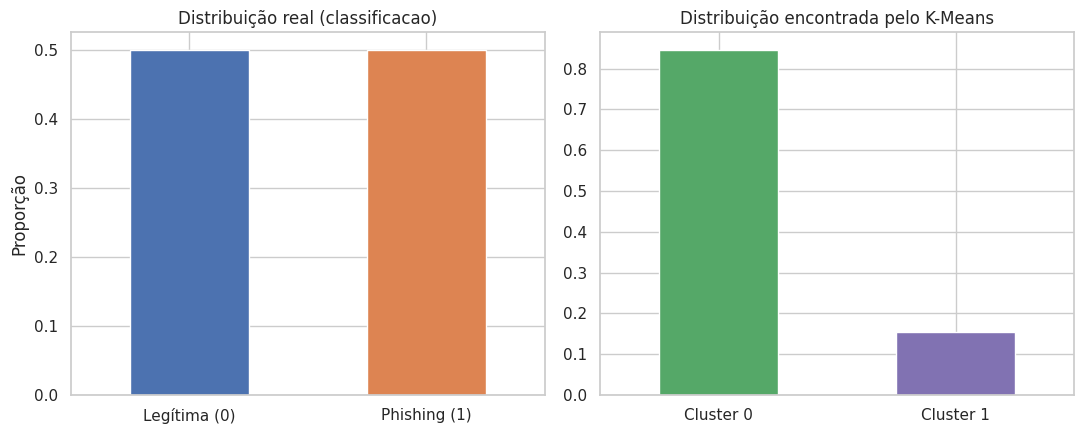

In [103]:
tamanho_clusters = df_cluster['cluster'].value_counts(normalize=True).sort_index()
tamanho_clusters.index = ['Cluster 0', 'Cluster 1']

print("Proporção de cada cluster encontrado pelo K-Means:")
print(tamanho_clusters)
print("\nProporção real das classes:")
print(prop_real)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

prop_real.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Distribuição real (classificacao)')
axes[0].set_ylabel('Proporção')
axes[0].tick_params(axis='x', rotation=0)

tamanho_clusters.plot(kind='bar', ax=axes[1], color=['#55A868', '#8172B2'])
axes[1].set_title('Distribuição encontrada pelo K-Means')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Compare os dois percentuais impressos acima: se ficarem próximos (ex. ~50/50
# nos dois), o clustering "bateu" com a proporção real; se um dos clusters
# ficar bem maior que o outro (ex. 80/20), não bateu.

#### 5.4 Matriz de contingência (cluster x classe real) com alinhamento do cluster majoritário

Matriz de contingência (contagens absolutas):


Classe real,0,1
Cluster,,
0,1145,791
1,12,338



Mapeamento cluster -> classe majoritária: {0: 0, 1: 1}

'Acerto' do K-Means após alinhamento dos clusters: 0.6487
Adjusted Rand Index (concordância cluster x classe, corrigida pelo acaso): 0.0882


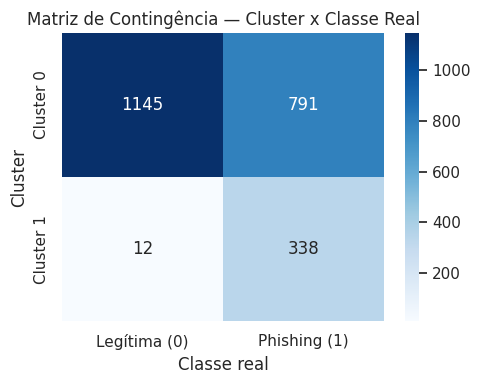

In [104]:
contingencia = pd.crosstab(
    df_cluster['cluster'], df_cluster['classe_real'],
    rownames=['Cluster'], colnames=['Classe real']
)
print("Matriz de contingência (contagens absolutas):")
display(contingencia)

# O número do cluster (0 ou 1) é arbitrário — antes de calcular "acerto",
# alinhamos o cluster majoritário com a classe majoritária dentro dele.
mapa_cluster_para_classe = contingencia.idxmax(axis=1).to_dict()
print("\nMapeamento cluster -> classe majoritária:", mapa_cluster_para_classe)

df_cluster['classe_predita_pelo_cluster'] = df_cluster['cluster'].map(mapa_cluster_para_classe)

acerto = (df_cluster['classe_predita_pelo_cluster'] == df_cluster['classe_real']).mean()
ari = adjusted_rand_score(df_cluster['classe_real'], df_cluster['cluster'])

print(f"\n'Acerto' do K-Means após alinhamento dos clusters: {acerto:.4f}")
print(f"Adjusted Rand Index (concordância cluster x classe, corrigida pelo acaso): {ari:.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(
    contingencia, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Legítima (0)', 'Phishing (1)'],
    yticklabels=['Cluster 0', 'Cluster 1']
)
plt.title('Matriz de Contingência — Cluster x Classe Real')
plt.tight_layout()
plt.show()

#### **Como interpretar o "acerto" acima:** um ARI próximo de 0 significa que a divisão em clusters é essencialmente aleatória em relação ao rótulo real (o K-Means não "descobriu" a diferença phishing/legítima sozinho). Um ARI alto (perto de 1) significa que os dois clusters recuperam quase perfeitamente a divisão phishing/legítima, mesmo sem nunca ter visto o rótulo.

#### 5.5 Quais features mais separam os clusters? Comparação com a Feature Importance do modelo supervisionado

Top 15 features que mais separam os dois clusters (K-Means):


,Feature,Diferenca_absoluta_centroides
0,endereco_ip,2.224159
1,proporcao_digitos_url,1.913734
2,tamanho_url,1.723091
3,tamanho_palavras_brutas,1.451537
4,maior_palavra_caminho,1.386524
5,tld_no_subdominio,1.363181
6,caracteres_especiais,1.349242
7,maior_palavra_bruta,1.227373
8,media_palavras_caminho,1.205685
9,quantidade_palavra_com,1.122012



Top 15 features mais importantes no modelo supervisionado (XGBoost, permutation importance):


,Feature,Importância
0,rank_da_pagina,0.066895
1,indexado_google,0.032461
2,quantidade_palavra_www,0.020629
3,quantidade_barras(/),0.007250
4,indicadores_phishing,0.007183
5,tamanho_palavras_brutas,0.005913
6,idade_dominio,0.005326
7,quantidade_pontos(.),0.004892
8,quantidade_hiperlinks,0.004673
9,token_https,0.003321



Features em comum entre os Top 15 de cada abordagem: 4 de 15
{'quantidade_barras(/)', 'indexado_google', 'tamanho_palavras_brutas', 'quantidade_pontos(.)'}


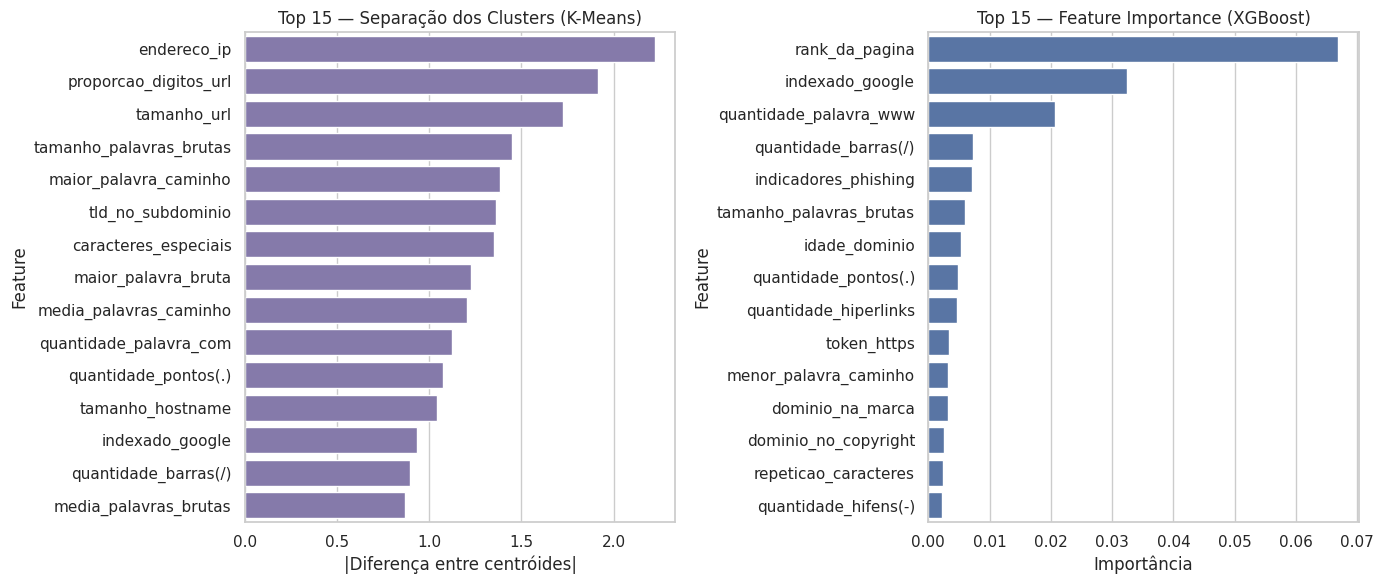

In [105]:
# Os centróides do K-Means já estão em escala padronizada (mesma escala usada
# para treinar o modelo supervisionado), então a diferença absoluta entre eles,
# feature a feature, indica quais variáveis mais empurram a distância entre os
# dois clusters — o equivalente, em clustering, a uma "feature importance".

centroides = kmeans.cluster_centers_
diferenca_centroides = pd.DataFrame({
    'Feature': X_scaled_full.columns,
    'Diferenca_absoluta_centroides': np.abs(centroides[0] - centroides[1])
}).sort_values('Diferenca_absoluta_centroides', ascending=False).reset_index(drop=True)

print("Top 15 features que mais separam os dois clusters (K-Means):")
display(diferenca_centroides.head(15))

print(f"\nTop 15 features mais importantes no modelo supervisionado ({melhor_modelo_nome}, permutation importance):")
display(imp_df.head(15))

top_cluster        = set(diferenca_centroides.head(15)['Feature'])
top_supervisionado = set(imp_df.head(15)['Feature'])
interseccao        = top_cluster & top_supervisionado

print(f"\nFeatures em comum entre os Top 15 de cada abordagem: {len(interseccao)} de 15")
print(interseccao)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=diferenca_centroides.head(15), x='Diferenca_absoluta_centroides', y='Feature',
            color='#8172B2', ax=axes[0])
axes[0].set_title('Top 15 — Separação dos Clusters (K-Means)')
axes[0].set_xlabel('|Diferença entre centróides|')

sns.barplot(data=imp_df.head(15), x='Importância', y='Feature', color='#4C72B0', ax=axes[1])
axes[1].set_title(f'Top 15 — Feature Importance ({melhor_modelo_nome})')

plt.tight_layout()
plt.show()

**Pergunta de reflexão final:** *olhem quais features mais influenciam a separação dos clusters e comparem com as features mais importantes do modelo supervisionado. Elas são as mesmas?*

Depois de rodar a célula acima, observem o valor de `len(interseccao)` (quantas das Top 15 features coincidem nas duas listas) e completem com o cenário correspondente:

- **Se a interseção for alta (a maioria das Top 15 coincide)** → o problema é "naturalmente" separável: a estrutura de distância nas features já carrega, por si só, o sinal que separa phishing de legítima. Isso é um bom sinal de robustez do problema — significa que várias abordagens diferentes (supervisionadas ou não) tendem a chegar a conclusões parecidas sobre o que importa.
- **Se a interseção for baixa (poucas features em comum)** → isso é um insight de negócio real: o que o modelo supervisionado aprendeu como "sinal de phishing" (ex.: relações não-lineares e combinações entre features, que o XGBoost capta mas a distância euclidiana simples do K-Means não) é mais sutil do que a simples proximidade no espaço de features. Nesse caso, o K-Means está separando os dados por outro critério (ex.: tamanho da URL, tráfego), que não é exatamente o que diferencia phishing de site legítimo.

> Personalizem esse parágrafo com o valor real de interseção que aparecer quando vocês rodarem a célula — o texto acima cobre os dois cenários possíveis para vocês escolherem o que corresponde ao resultado de vocês.
